# **ANALYSE**<br> _RECONNAISSANCE ET FRANCHISES DES CATNAT_

Les données utilisées ont été scrappées du site : https://www.ccr.fr/portail-catastrophes-naturelles/liste-arretes/

## __IMPORTS__

In [137]:
# Installations
! uv pip install seaborn morethemes pyfonts pypalettes drawarrow dayplot contextily geopandas tqdm imageio

Using Python 3.13.9 environment at: C:\Users\Asus\Documents\14_PrixChangementClimatique\.venv
Resolved 43 packages in 534ms
Installed 2 packages in 112ms
 + imageio==2.37.2
 + tqdm==4.67.3


In [2]:
import duckdb

# The usual suspects
import numpy as np
import pandas as pd

# Chart and Figure
import seaborn as sns
import matplotlib
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

# Fonts, Palettes, Themes, Arrow (https://github.com/y-sunflower)
# Strong inspiration: https://www.yan-holtz.com/
import morethemes as mt
from pyfonts import load_google_font, load_font
from pypalettes import load_palette, load_cmap
from drawarrow import fig_arrow
import dayplot as dp # Calendar plot for timeseries

# GeoSpatial
import contextily as ctx
from shapely.affinity import translate, scale
import geopandas as gpd

# GIF
import imageio
from tqdm import tqdm

# Removing warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Setup
font = load_google_font("Montserrat", italic=False) # check here: https://fonts.google.com/
mt.set_theme("nature") # Main color for text is not black, but cool layout

source_text = "Source: CCR (Caisse Centrale de Réassurance)" # Main Source for the analysis

## __LOAD DATA__

In [4]:
PCC_DUCKDB_FILE = "dev.duckdb"
con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)

In [5]:
query_ccr_main = """
SELECT
	*
FROM dev.main.ccr_main_page
"""

ccr_main = con.sql(query_ccr_main)
ccr_main_df = ccr_main.df()
ccr_main_df.head(2)

,codePeril,nomPeril,dateArrete,dateParutionJO,codeNOR,codeInseePole,codeArrete
0,None,"Inondations et/ou Coulées de Boue, Inondations...",2026-01-19,2026-01-24,INTE2601369A,None,904
1,None,Sécheresse,2025-12-12,2025-12-13,INTE2534330A,None,903


In [6]:
query_ccr_details = """
SELECT
	*
FROM dev.main.ccr_details
"""

ccr_details = con.sql(query_ccr_details)
ccr_details_df = ccr_details.df()
ccr_details_df.head(2)

,codeInsee,nomCommune,dateDebutEvenement,dateFinEvenement,dateArrete,dateParutionJO,nomPeril,franchise,libelleAvis,code_arrete
0,07005,ALBA LA ROMAINE,2025-11-16,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,-,Non reconnue,904
1,07022,BAIX,2025-11-16,2025-11-17,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,Simple,Reconnue,904


In [7]:
details_par_catnat = ccr_details_df.copy()

details_par_catnat["nomPeril"] = (
    details_par_catnat["nomPeril"]
    .mask(details_par_catnat["nomPeril"].str.contains("Inondations"), "Inondations")
    .where(details_par_catnat["nomPeril"].str.contains("Inondations|Sécheresse"), "Autre")
)

details_par_catnat = details_par_catnat[(details_par_catnat["dateArrete"].dt.year > 1983) & (details_par_catnat["dateArrete"].dt.year < 2026)]
details_par_catnat['periode_2010'] = np.where(
    details_par_catnat['dateArrete'].dt.year < 2010, 
    'Avant 2010', 
    'Après 2010'
)

avis_par_catnat = (
    details_par_catnat.groupby(
        [pd.Grouper(key="dateArrete", freq="YE"), "nomPeril", "libelleAvis", "periode_2010"]
    )
    .size()
    .reset_index(name="count")
)

franchise_par_catnat = details_par_catnat.copy()
franchise_par_catnat = franchise_par_catnat[
    franchise_par_catnat["libelleAvis"] == "Reconnue"
]

franchise_par_catnat['franchise'] = franchise_par_catnat["franchise"].replace(
                                                          {"Doublée":"Doublée ou plus",
                                                           "Triplée":"Doublée ou plus",
                                                           "Quadruplée":"Doublée ou plus"})
franchise_par_catnat = (
    franchise_par_catnat.groupby(
        [pd.Grouper(key="dateArrete", freq="YE"), "nomPeril", "franchise", "periode_2010"]
    )
    .size()
    .reset_index(name="count")
)

### GEOSPATIAL

In [50]:
dept_geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-avec-outre-mer.geojson"
communes_geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes-avec-outre-mer.geojson"

dept_geo = gpd.read_file(dept_geojson_url)
communes_geo = gpd.read_file(communes_geojson_url)

## __CHART & FIGURES__

### GLOBAL CATNAT EVOLUTION

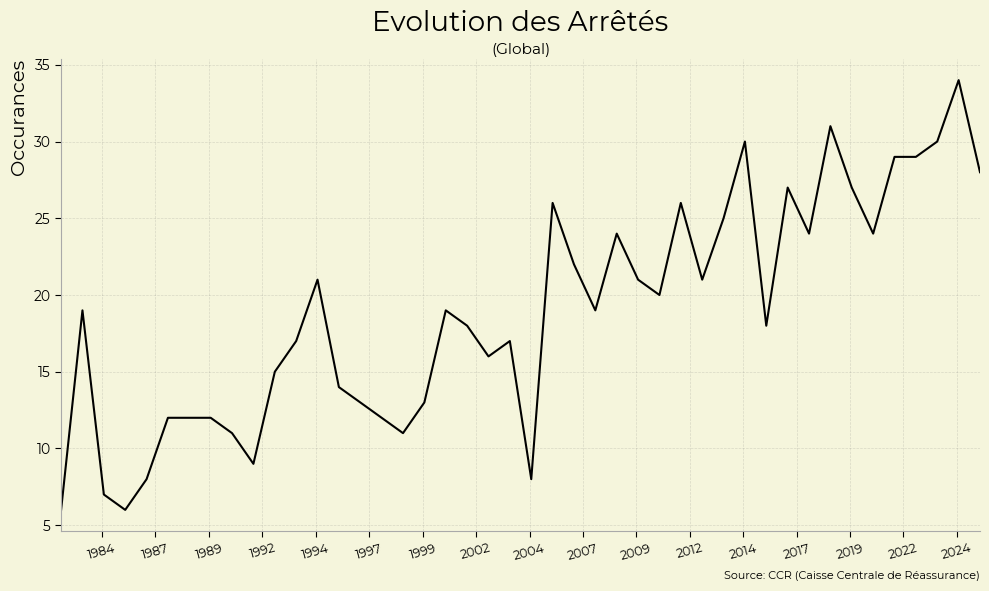

In [49]:
def global_evolution_catnat(df, 
                            font=None,
                            resample="YE",
                            source_text=source_text,
                            figsize=(10, 6)):
    """
    Plot the global evolution of catnat over time.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing a column named "dateArrete" with dates of decrees.
    font : str or matplotlib.font_manager.FontProperties, optional
        Font to use for text elements in the plot. If None, uses the default font.
    resample : str, default="YE"
        Resampling frequency for the time series (e.g., "YE" for year-end, "M" for month-end).
    source_text : str, optional
        Text to display as the source of the data, typically at the bottom of the plot.
    figsize : tuple of int, default=(10, 6)
        Figure size in inches (width, height).

    Returns
    -------
    matplotlib.figure.Figure
        The generated figure object containing the plot.

    Notes
    -----
    - The "dateArrete" column in the DataFrame must be in the format "%d-%m-%Y".
    - The plot is limited to data up to the year 2025.
    - The x-axis is formatted according to the resampling frequency.
    """
    
    # Data Prep
    df_plot = df.copy()
    df_plot["dateArrete"] = pd.to_datetime(df_plot["dateArrete"], format="%d-%m-%Y")

    df_grouped = (
        df_plot.set_index("dateArrete")
        .resample(resample)
        .size()
        .reset_index(name="count")
        .set_index("dateArrete")
        .loc[:"2025"] # Limit to 2025 for visual purposes
    )

    # Plotting Time series
    fig, ax = plt.subplots(figsize=figsize)
    plt.plot(
        df_grouped.index,
        df_grouped["count"],
        linestyle="-",
        color="black",
    )

    # Title
    plt.title("Evolution des Arrêtés", 
              font=font, 
              fontsize=20, 
              color="black", 
              pad=20)

    # Subtitle
    plt.text(
        0.5,
        1.01,
        "(Global)",
        font=font,
        fontsize=11,
        color="black",
        ha="center",
        transform=ax.transAxes,
    )
    plt.xlabel("")
    plt.ylabel("Occurances", font=font, fontsize=14, color="black")

    # Formatting x axis
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%"+resample[:-1]))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=30)) # by reducing this number you increase number of ticks

    # Axis ticks
    plt.xticks(font=font, rotation=15, fontsize=9)
    plt.yticks(font=font, fontsize=10)
    plt.xlim([df_grouped.index.min(), pd.to_datetime("2025-12-31")])

    # Source Info
    plt.text(
        1,
        -0.105,
        source_text,
        ha="right",
        va="bottom",
        transform=ax.transAxes,
        fontsize=8,
        color="black",
        font=font,
    )

    plt.tight_layout()
    return fig

global_evolution_catnat(df=ccr_main_df, font=font);

### CALENDAR PLOT

In [8]:
main_data_occur_total = ccr_main_df.groupby("dateArrete").size()

# All Inodations type are converted into Inondations
# Other péril are just Autre
ccr_main_df["nomPeril"] = (
    ccr_main_df["nomPeril"]
    .mask(ccr_main_df["nomPeril"].str.contains("Inondations"), "Inondations")
    .where(ccr_main_df["nomPeril"].str.contains("Inondations|Sécheresse"), "Autre")
)

main_data_occur_inond = ccr_main_df[ccr_main_df["nomPeril"] == "Inondations"].groupby("dateArrete").size()
main_data_occur_secheresse = ccr_main_df[ccr_main_df["nomPeril"] == "Sécheresse"].groupby("dateArrete").size()

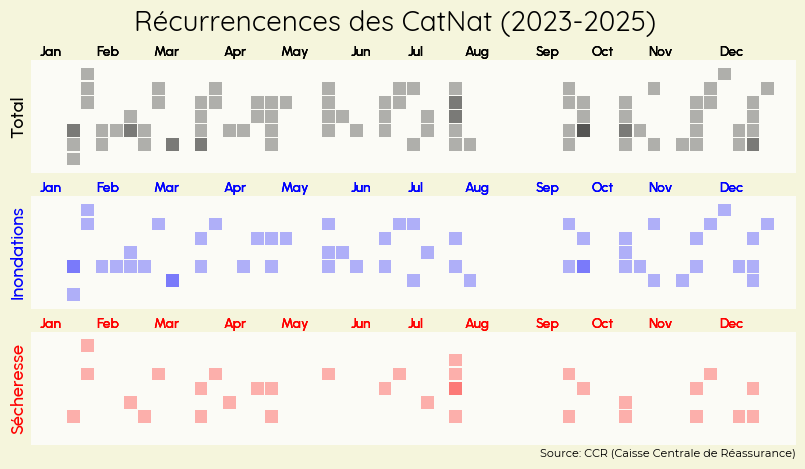

In [63]:
font_url = "https://github.com/coreyhu/Urbanist/blob/main/fonts/ttf"
fontyear = load_font(f"{font_url}/Urbanist-Medium.ttf?raw=true")

start_year = 2023 # Change start
end_year = 2025
years_to_plot = range(start_year, end_year + 1)

style_args = dict(
    day_kws={"alpha": 0}, # Hide day borders
    month_kws={"font": fontyear, "size": 10},
    month_y_margin=-8.5, # Month label position
    color_for_none="None", # None/Transparent background for stacking
    alpha=0.3
)

data = [main_data_occur_total, main_data_occur_inond, main_data_occur_secheresse]
titles = ["Total", "Inondations", "Sécheresse"]
colors_band = ["black", "blue", "red"] 
cmaps = [LinearSegmentedColormap.from_list("monochrome", [colors_band[0], colors_band[0]]),
         LinearSegmentedColormap.from_list("monochrome", [colors_band[1], colors_band[1]]),
         LinearSegmentedColormap.from_list("monochrome", [colors_band[2], colors_band[2]])]

# The idea her is overlay calendars, 
# colored box will then overlay and increase in color intesity by stacking
fig, axs = plt.subplots(nrows=3, figsize=(15, 5))

for i, (df_cal, color, title) in enumerate(zip(data, colors_band, titles)):
    for _, year in enumerate(years_to_plot):
        subset = df_cal[df_cal.index.year == year].copy()

        if subset.empty: continue # No péril of that type during this specific year

        try:
            delta_years = end_year - year
            subset.index = subset.index + pd.offsets.DateOffset(years=delta_years)
        except ValueError:
            subset = subset[~((subset.index.month == 2) & (subset.index.day == 29))] # For Febraury
            subset.index = subset.index.map(lambda d: d.replace(year=end_year))

        # Modifying color of calendar layers
        layer_style = style_args.copy()
        layer_style['cmap'] = cmaps[i]
        layer_style['month_kws']["color"] = color

        dp.calendar(
            subset.index,
            subset.values,
            start_date=f"{end_year}-01-01",
            end_date=f"{end_year}-12-31",
            ax=axs[i],
            **layer_style
        )

    axs[i].text(
        x=-2, y=3.5, 
        s=title, 
        size=13, rotation=90, 
        color=color, 
        va="center", font=fontyear
    )

    axs[i].set_facecolor("#FBFBF6") # You can change this, it is to match with "nature" theme

plt.suptitle(f"Récurrencences des CatNat ({start_year}-2025)", fontsize=20, color="black")

plt.text(
        1,
        -0.125,
        source_text,
        ha="right",
        va="bottom",
        transform=axs[-1].transAxes,
        fontsize=8,
        color="black",
        font=font,
    )

plt.show()

### STRIPES PLOT

In [78]:
# Modifying details data
ccr_details_df["dateArrete"] = pd.to_datetime(ccr_details_df["dateArrete"])
ccr_details_df["libelleAvis"] = ccr_details_df["libelleAvis"].replace(
    {
        "Reconnue(sans impact sur la modulation)": "Reconnue"
    }
)

ccr_details_df = ccr_details_df[~ccr_details_df.duplicated()] # Error dans CCR https://www.ccr.fr/detail-arrete/?codeArrete=000888
ccr_details_df.head(2)

,codeInsee,nomCommune,dateDebutEvenement,dateFinEvenement,dateArrete,dateParutionJO,nomPeril,franchise,libelleAvis,code_arrete
0,07005,ALBA LA ROMAINE,2025-11-16,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,-,Non reconnue,904
1,07022,BAIX,2025-11-16,2025-11-17,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,Simple,Reconnue,904


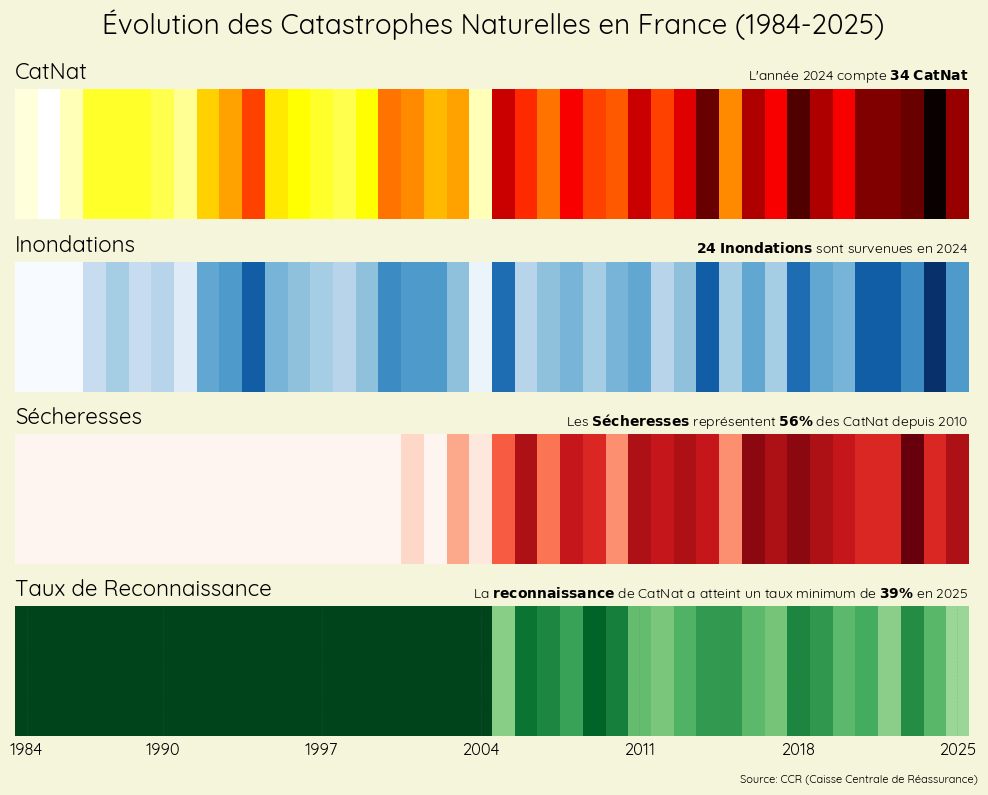

In [233]:
annual_counts = main_data_occur_total.loc["1984":"2025"].resample('YE').sum()
annual_counts_inond = main_data_occur_inond.loc["1984":"2025"].resample('YE').sum()
annual_counts_secheresse = main_data_occur_secheresse.loc["1984":"2025"].resample('YE').sum()

# Recon
recon = ccr_details_df.copy()
recon = recon.groupby([ccr_details_df["dateArrete"].dt.year, "libelleAvis"]).size().unstack(fill_value=0)

recon["ratio_recon"] = (
    recon["Reconnue"] / recon.sum(axis=1)
) * 100


all_years = annual_counts.index

data_total = annual_counts.values.reshape(1, -1)
data_inond = annual_counts_inond.reindex(all_years, fill_value=0).values.reshape(1, -1)
data_sech = annual_counts_secheresse.reindex(all_years, fill_value=0).values.reshape(1, -1)
data_recon = recon["ratio_recon"].loc["1984":"2025"].values.reshape(1,-1)


fig, axs = plt.subplots(nrows=4, figsize=(10, 8))

# CatNat
img = axs[0].imshow(data_total, cmap='hot_r', aspect='auto', interpolation='nearest')
axs[0].set_axis_off()

axs[0].set_title("CatNat", 
          loc='left', 
          pad=7.5,
          fontsize=16, 
          color='black')

# Inondations
img = axs[1].imshow(data_inond, cmap='Blues', aspect='auto', interpolation='nearest')
axs[1].set_axis_off()

axs[1].set_title("Inondations", 
          loc='left', 
          pad=7.5,
          fontsize=16, 
          color='black')

# Sécheresse
img = axs[2].imshow(data_sech, cmap='Reds', aspect='auto', interpolation='nearest')
axs[2].set_axis_off()

axs[2].set_title("Sécheresses", 
          loc='left', 
          pad=7.5,
          fontsize=16, 
          color='black')

# Recon
img = axs[3].imshow(data_recon, 
                    cmap='Greens',
                    aspect='auto', 
                    interpolation='nearest',
                    vmin=0, 
                    vmax=100)

axs[3].set_title("Taux de Reconnaissance", 
          loc='left', 
          pad=7.5,
          fontsize=16, 
          color='black')

# Axis
tick_indices = np.linspace(0, len(all_years) - 1, 7, dtype=int)

axs[3].set_xticks(tick_indices)
axs[3].set_xticklabels([all_years.year[i] for i in tick_indices], 
                       fontsize=12, 
                       fontweight='bold',
                       color='black')

axs[3].tick_params(axis='x', which='both', length=0)

for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_yticks([])

# Titles and  Annotations
plt.suptitle("Évolution des Catastrophes Naturelles en France (1984-2025)", 
             color='black', 
             fontsize=20,
             fontweight='bold',
             y=0.99)

axs[0].text(
    1,          
    1.1,        
    r"L'année 2024 compte $\bf{34}$ $\bf{CatNat}$", 
    transform=axs[0].transAxes,
    ha="right", 
    va="center", 
    fontsize=10, 
    color="black",
)

axs[1].text(
    1,          
    1.1,        
    r"$\bf{24}$ $\bf{Inondations}$ sont survenues en 2024", 
    transform=axs[1].transAxes,
    ha="right", 
    va="center", 
    fontsize=10, 
    color="black",
)

axs[2].text(
    1,          
    1.1,        
    r"Les $\bf{Sécheresses}$ représentent $\bf{56\%}$ des CatNat depuis 2010", 
    transform=axs[2].transAxes,
    ha="right", 
    va="center", 
    fontsize=10, 
    color="black",
)

axs[3].text(
    1,          
    1.1,        
    r"La $\bf{reconnaissance}$ de CatNat a atteint un taux minimum de $\bf{39\%}$ en 2025", 
    transform=axs[3].transAxes,
    ha="right", 
    va="center", 
    fontsize=10, 
    color="black",
)

plt.text(
        1.01,
        -0.375,
        source_text,
        ha="right",
        va="bottom",
        transform=axs[3].transAxes,
        fontsize=8,
        color="black",
        )

plt.savefig("CatNat_Stripes_Vector.pdf", facecolor=fig.get_facecolor(), bbox_inches='tight')

plt.tight_layout()
plt.savefig(
    "Evolution_CatNat_France_1982_2025.png", 
    dpi=300, 
    facecolor=fig.get_facecolor(),  
    edgecolor='none',
    bbox_inches='tight',           
    pad_inches=0.5                 
)

plt.show()

### BAR CHART LIBELLE AVIS

In [43]:
# Modifying details data
ccr_details_df["dateArrete"] = pd.to_datetime(ccr_details_df["dateArrete"])
ccr_details_df["libelleAvis"] = ccr_details_df["libelleAvis"].replace(
    {
        "Reconnue(sans impact sur la modulation)": "Reconnue"
    }
)

ccr_details_df = ccr_details_df[~ccr_details_df.duplicated()] # Error dans CCR https://www.ccr.fr/detail-arrete/?codeArrete=000888
ccr_details_df.head(2)

,codeInsee,nomCommune,dateDebutEvenement,dateFinEvenement,dateArrete,dateParutionJO,nomPeril,franchise,libelleAvis,code_arrete
0,07005,ALBA LA ROMAINE,2025-11-16,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,-,Non reconnue,904
1,07022,BAIX,2025-11-16,2025-11-17,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,Simple,Reconnue,904


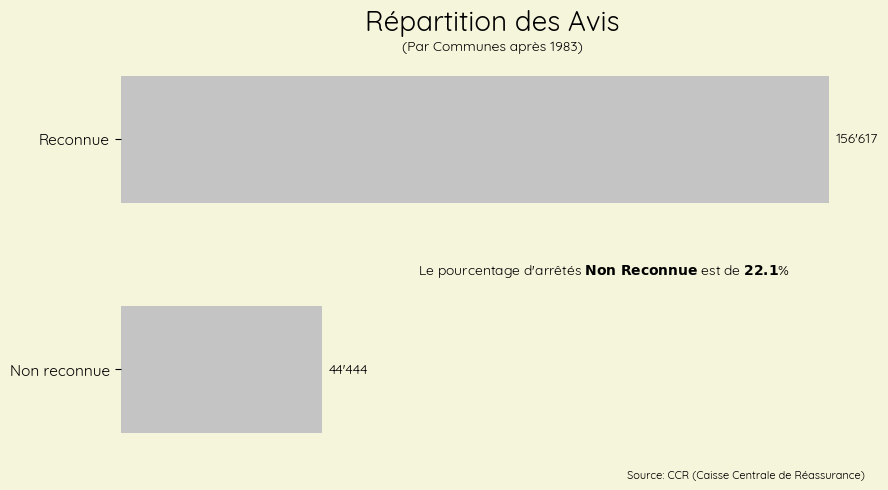

In [48]:
def bar_distribution(df, 
                     font=None,
                     figsize=(9, 5),
                     filter_year=1983,
                     color="#C4C4C4",
                     analysis="reconnaissance"):
    """
    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing columns "dateArrete", "libelleAvis", "franchise", and "nomCommune".
    font : str or matplotlib.font_manager.FontProperties, optional
        Font to use for text elements in the plot. If None, uses the default font.
    figsize : tuple of int, default=(9, 5)
        Figure size in inches (width, height).
    filter_year : int, default=1983
        Only include decrees from years after this value.
    color : str, default="#C4C4C4"
        Color of the bars in the plot.
    analysis : str, default="reconnaissance"
        Type of analysis to perform. Must be either "reconnaissance" or "franchise".
        - "reconnaissance": Plots the distribution of "libelleAvis".
        - "franchise": Plots the distribution of "franchise" for decrees with "Reconnue" status.

    Returns
    -------
    matplotlib.figure.Figure
        The generated figure object containing the bar plot.
    """
    df_plot = df.copy()
    df_plot = df_plot[df_plot["dateArrete"].dt.year > filter_year]

    if analysis == 'franchise':
        selected_col = "franchise"
        df_plot = df_plot[
            df_plot["libelleAvis"] == "Reconnue"
        ]
        title = "Répartition des Franchises"
    else:
        selected_col = "libelleAvis"
        title = "Répartition des Avis"

    df_plot = (
        df_plot.groupby(selected_col).count().sort_values(by="nomCommune")
    )

    fig, ax = plt.subplots(figsize=figsize)
    bars = plt.barh(
        df_plot.index, df_plot["nomCommune"], color=color, height=0.55
    )

    plt.title(title, font=font, fontsize=20, color="black", pad=20)
    plt.text(
        0.5,
        1.02,
        f"(Par Communes après {filter_year})",
        font=font,
        fontsize=10,
        color="black",
        ha="center",
        transform=ax.transAxes,
    )  # subtitle

    plt.ylabel("")

    # Removing axis
    plt.gca().axes.get_xaxis().set_visible(False)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)

    # Add labels to each bar
    for bar in bars:
        width = bar.get_width()
        plt.gca().text(
            width + 1500,
            bar.get_y() + bar.get_height() / 2.0,
            f"{int(width):,}".replace(",", "'"),
            ha="left",
            va="center",
            color="black",
            font=font,
        )

    plt.yticks(font=font, fontsize=11)

    if analysis == "reconnaissance":
        percent_nr = (
            df_plot["nomCommune"].loc["Non reconnue"]
            / df_plot["nomCommune"].sum()
        )

        plt.text(
            0.65,
            0.45,
            f"Le pourcentage d'arrêtés $\mathbf{{Non\ Reconnue}}$ est de $\mathbf{{{(percent_nr * 100).round(1)}}}$%",
            font=font,
            fontsize=10,
            color="black",
            ha="center",
            transform=ax.transAxes,
        )

    plt.text(
            1,
            -0.075,
            source_text,
            ha="right",
            va="bottom",
            transform=ax.transAxes,
            fontsize=8,
            color="black",
            font=font,
            )
    plt.grid(False)
    plt.tight_layout()
    return fig

bar_distribution(ccr_details_df, filter_year=1983);

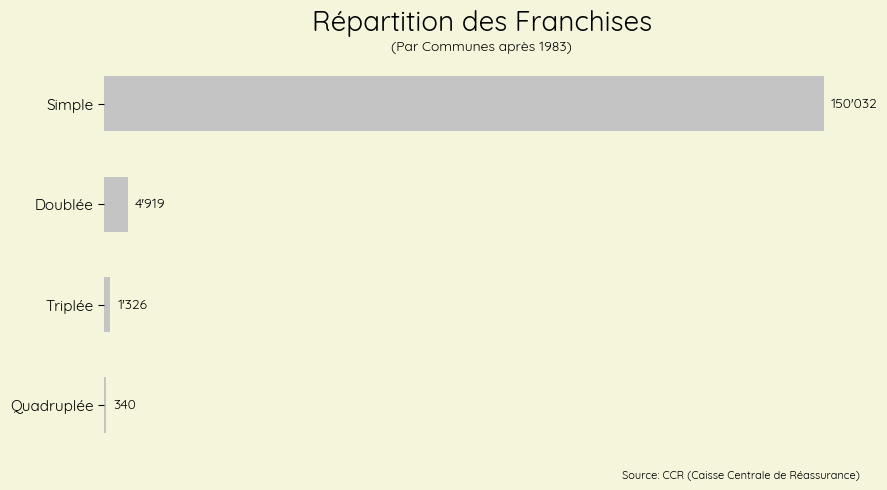

In [51]:
bar_distribution(ccr_details_df, filter_year=1983, analysis="franchise");

### PROGRESSION DE LA NON RECONNAISSANCE & FRANCHISES

In [53]:
def prepare_data_line_chart(df, 
                            group_freq="YE",
                            target_col="libelleAvis",
                            end_date="2025-12-31", 
                            remove_simple=True):
    df_plot = df.copy()
    if target_col == "franchise":
        df_plot = df_plot[(df_plot["libelleAvis"] != "Non reconnue") & \
                          ((df_plot[target_col] != "Simple") if remove_simple else True)]

    df_plot = (
        df_plot.groupby(
            [pd.Grouper(key="dateArrete", freq=group_freq), target_col]
        )
        .size()
        .reset_index(name="count")
    )

    df_plot = df_plot[
        df_plot["dateArrete"].dt.year <= 2026
    ]

    df_plot = df_plot.pivot(index="dateArrete", columns=target_col, values="count").fillna(0)
    df_plot = df_plot.loc[:end_date]

    return df_plot

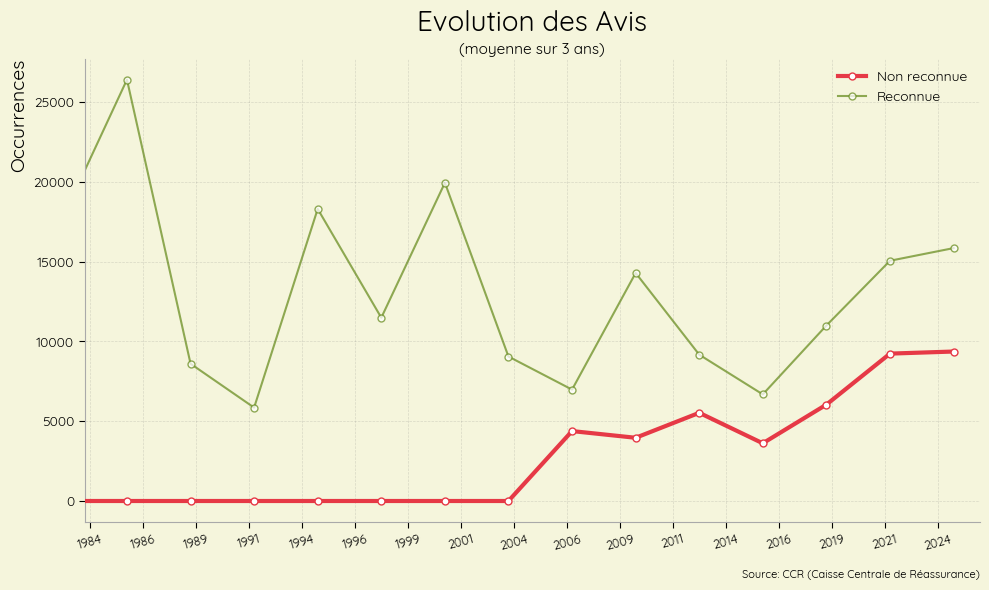

In [64]:
def line_chart_global(df, 
                      font=None,
                      group_freq="YE",
                      target_col="libelleAvis",
                      start_date="1984",
                      end_date="2025-12-31",
                      figsize=(10, 6)):

    annee = int(group_freq.split("YE")[0] or 1)
    df_plot = prepare_data_line_chart(df, 
                                      group_freq=group_freq,
                                      target_col=target_col,
                                      end_date=end_date)
    if target_col == "libelleAvis":
        title = "Evolution des Avis"
        subtitle = f"(moyenne sur {annee} ans)"
    else:
        title = "Evolution des Franchises"
        subtitle = f"(exclus franchise simple, moyenne sur {annee} ans)"

    fig, ax = plt.subplots(figsize=figsize)

    for column in df_plot.columns:
        if target_col == "libelleAvis":
                if "Non reconnue" in column:
                    color = "#e63946"
                    linewidth = 3
                    zorder = 5

                    ax.plot(
                        df_plot.index,
                        df_plot[column],
                        label=column,
                        color=color,
                        linewidth=linewidth,
                        marker="o",
                        linestyle="-",
                        ms=5,
                        markerfacecolor="white",
                        markeredgewidth=1,
                        zorder=zorder,
                    )
                else:
                    ax.plot(
                        df_plot.index,
                        df_plot[column],
                        label=column,
                        marker="o",
                        linestyle="-",
                        ms=5,
                        markerfacecolor="white",
                        markeredgewidth=1,
                        alpha=0.75,
                        zorder=1,
                    )
        else:
             ax.plot(
                    df_plot.index,
                    df_plot[column],
                    label=column,
                    marker="o",
                    linestyle="-",
                    ms=5,
                    markerfacecolor="white",
                    markeredgewidth=1,
                    alpha=1,
                    zorder=1,
                )

    plt.title(title, font=font, fontsize=20, color="black", pad=20)
    plt.text(
        0.5,
        1.01,
        subtitle,
        font=font,
        fontsize=11,
        color="black",
        ha="center",
        transform=ax.transAxes,
    )

    plt.xlabel("")
    plt.ylabel("Occurrences", font=font, fontsize=14, color="black")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=30))

    plt.xticks(font=font, rotation=15, fontsize=9)
    plt.yticks(font=font, fontsize=10)

    plt.xlim([pd.to_datetime(start_date), pd.to_datetime("2026-03-31")])

    ax.legend(prop=font, loc="upper right", 
              frameon=False, labelcolor="black")

    handles, labels = ax.get_legend_handles_labels()

    if target_col == "franchise":
        desired_order = ["Doublée", "Triplée", "Quadruplée"]

        order_map = dict(zip(labels, handles))
        new_handles = [order_map[l] for l in desired_order if l in order_map]
        new_labels = [l for l in desired_order if l in order_map]

        ax.legend(new_handles, new_labels, prop=font, loc="upper left", 
                  frameon=False, labelcolor="black")

    plt.text(
        1,
        -0.125,
        source_text,
        ha="right",
        va="bottom",
        transform=ax.transAxes,
        fontsize=8,
        color="black",
        font=font,
    )

    plt.tight_layout()
    return fig

line_chart_global(ccr_details_df, group_freq="3YE");

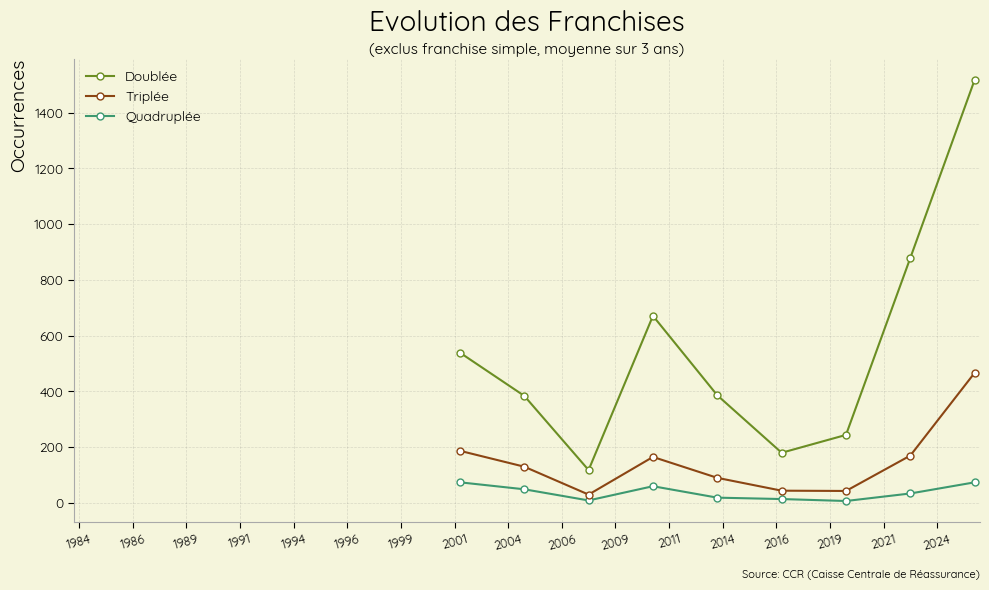

In [60]:
line_chart_global(ccr_details_df, group_freq="3YE", target_col="franchise");

### _PROGRESSION TAUX NON-RECONNAISSANCE_

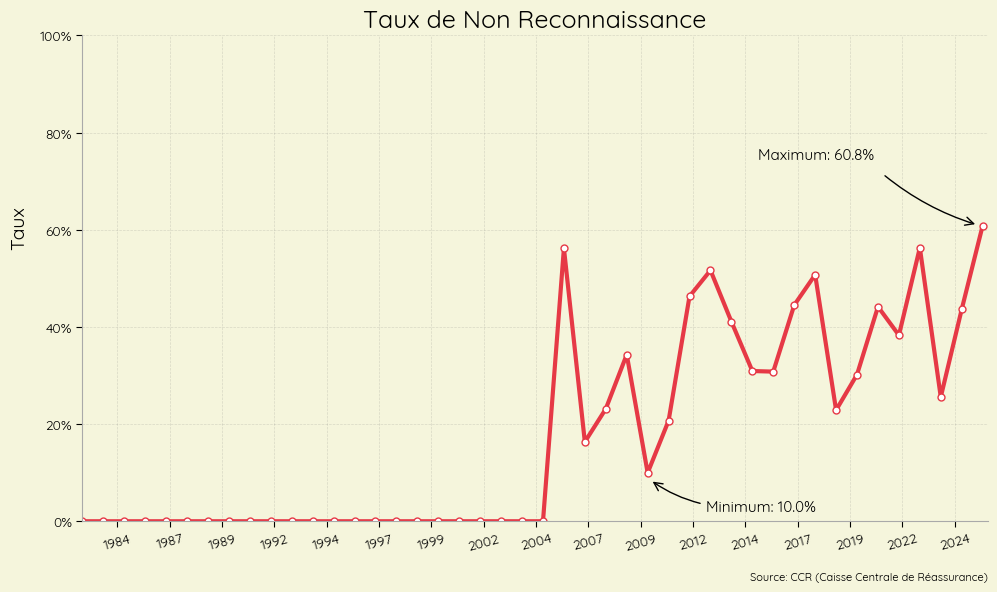

In [69]:
def add_arrow_indicators(ax, df, font=None, indicators_config=None):
    if indicators_config is None:
        indicators_config = {
            "Maximum": {
                "val": df.max(),
                "head": (0.975, 0.615),
                "tail": (0.88, 0.7),
                "radius": 0.1,
                "text_pos": (0.875, 0.74)
            },
            "Minimum": {
                "val": df[df > 0].min(),
                "head": (0.6475, 0.19),
                "tail": (0.7, 0.15),
                "radius": -0.1,
                "text_pos": (0.81, 0.015)
            }
        }

    for label, cfg in indicators_config.items():
        fig_arrow(
            head_position=cfg["head"],
            tail_position=cfg["tail"],
            radius=cfg["radius"],
            width=1, 
            color="black",
            fill_head=False, 
            mutation_scale=0.75, 
        )

        ax.text(
            cfg["text_pos"][0], 
            cfg["text_pos"][1],
            f"{label}: {cfg['val']*100:.1f}%",
            ha="right", 
            va="bottom", 
            transform=ax.transAxes,
            fontsize=11, 
            color="black", 
            fontproperties=font
        )



def line_chart_taux(df, font=None, 
                    group_freq="YE", 
                    target_col="libelleAvis", 
                    end_date="2025-12-31", 
                    indicators_positions=None):

    df_plot = df.copy()
    if target_col == "libelleAvis":
        select_cols = ["Non reconnue", "Reconnue"]
        title="Taux de Non Reconnaissance"
    else:
        df_plot['franchise'] = df_plot["franchise"].replace(
                                                          {"Doublée":"Doublée ou plus",
                                                           "Triplée":"Doublée ou plus",
                                                           "Quadruplée":"Doublée ou plus"})
        select_cols = ["Doublée ou plus", "Simple"]
        title="Taux de Franchises 'Doublée ou plus'"

    df_plot = prepare_data_line_chart(
        df_plot, group_freq=group_freq, target_col=target_col, end_date=end_date, remove_simple=False
    )

    total = df_plot[select_cols[0]] + df_plot[select_cols[1]]
    df_plot = df_plot[select_cols[0]] / total.replace(0, 1)
    df_plot = df_plot.loc[:end_date]

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='#F5F5DC')

    ax.plot(
        df_plot.index, df_plot,
        color="#e63946", linewidth=3, marker="o", ms=5,
        markerfacecolor="white", markeredgewidth=1
    )

    if target_col == "libelleAvis":
        add_arrow_indicators(ax, df_plot, font=font, indicators_config=indicators_positions)

    ax.set_title(title, fontproperties=font, fontsize=18, color="black")
    ax.set_ylabel("Taux", fontproperties=font, fontsize=14, color="black")
    ax.yaxis.set_label_coords(-0.06, 0.65)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=30))
    plt.xticks(rotation=15, fontsize=9, fontproperties=font)
    ax.set_xlim([df_plot.index.min(), pd.to_datetime("2026-03-31")])

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylim(0.0, 1.0)
    plt.yticks(fontsize=10, fontproperties=font)

    ax.legend(prop=font, loc="upper right", frameon=False)
    ax.text(
        1, -0.125, source_text, ha="right", va="bottom", 
        transform=ax.transAxes, fontsize=8, color="black", fontproperties=font
    )

    # Clean Spines
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    return fig

line_chart_taux(ccr_details_df);

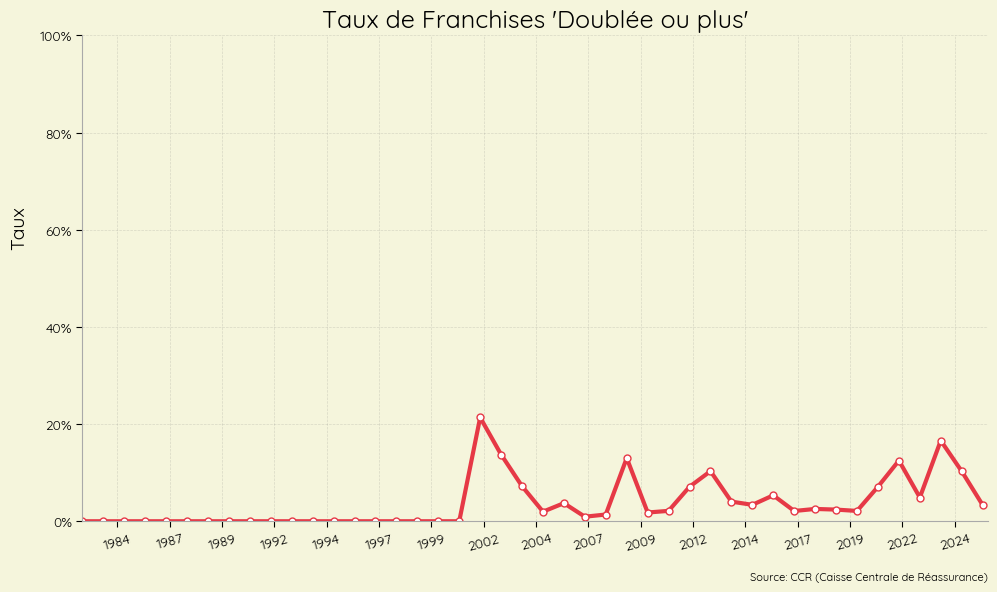

In [72]:
line_chart_taux(ccr_details_df, target_col="franchise");

### DONUT GLOBAL PAR CATNAT

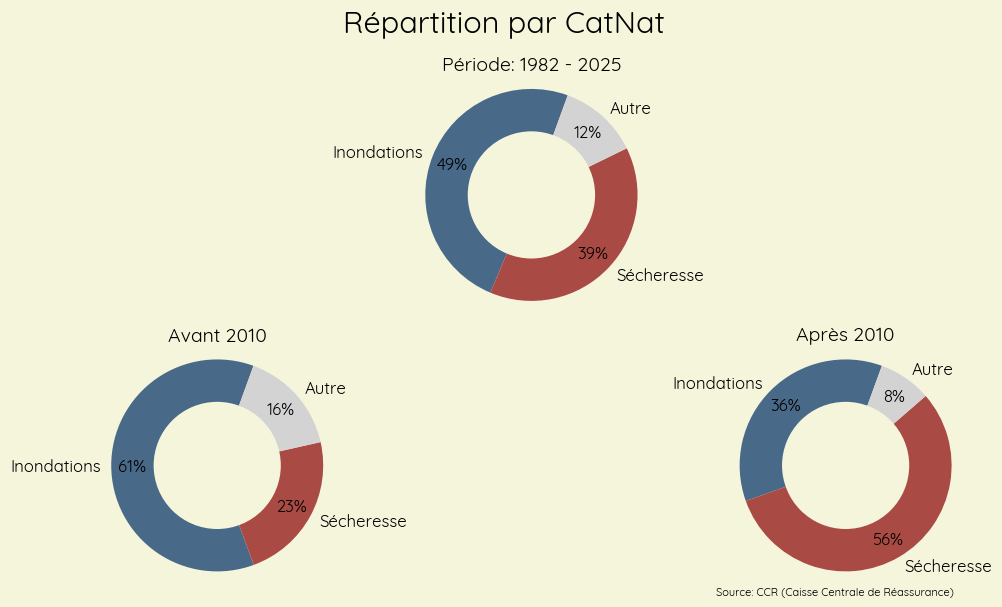

In [75]:
def donut_global_type_catnat(df, font=None):

    df_plot = df.copy()
    peril_order = ['Inondations', 'Sécheresse', 'Autre']

    def get_ordered_counts(df, order):
        counts = df['nomPeril'].value_counts().reindex(order)
        return counts.values, counts.index

    sizes_total, labels_total = get_ordered_counts(df, peril_order)

    df_avant = df_plot[df_plot['periode_2010'] == "Avant 2010"]
    sizes_avant, labels_avant = get_ordered_counts(df_avant, peril_order)

    df_apres = df_plot[df_plot['periode_2010'] == "Après 2010"]
    sizes_apres, labels_apres = get_ordered_counts(df_apres, peril_order)

    sizes = [sizes_total, sizes_avant, sizes_apres]
    labels = [labels_total, labels_avant, labels_apres]

    layout = """
        AAA
        B.C
    """
    fig, ax_dict = plt.subplot_mosaic(layout, figsize=(10, 6))

    def draw_donut(ax, sizes, labels, title, colors, main=False):
        ax.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%', 
               startangle=70, pctdistance=0.80, textprops={'fontproperties': font, "color":"black", "fontsize":12})

        centre_circle = plt.Circle((0,0), 0.6, fc='#F5F5DC')
        ax.add_artist(centre_circle)

        ax.axis('equal')
        ax.set_title(title, fontproperties=font, fontsize=14, color="black")


    colors_main = ['#496988', '#AA4A44', 'lightgrey', '#ffcc99']
    draw_donut(ax_dict['A'], sizes[0], labels[0], "Période: 1982 - 2025", colors_main)
    draw_donut(ax_dict['B'], sizes[1], labels[1], "Avant 2010", colors_main)
    draw_donut(ax_dict['C'], sizes[2], labels[2], "Après 2010", colors_main)

    fig.text(
        0.95,          
        0.0,          
        source_text,
        ha="right",
        va="bottom",
        fontsize=8,
        color="black",
        font=font,
    )

    plt.suptitle("Répartition par CatNat", font=font, color="black", fontsize=22)
    plt.tight_layout()

    return fig

donut_global_type_catnat(details_par_catnat);

### DONUT SPECIFIC PAR CATNAT

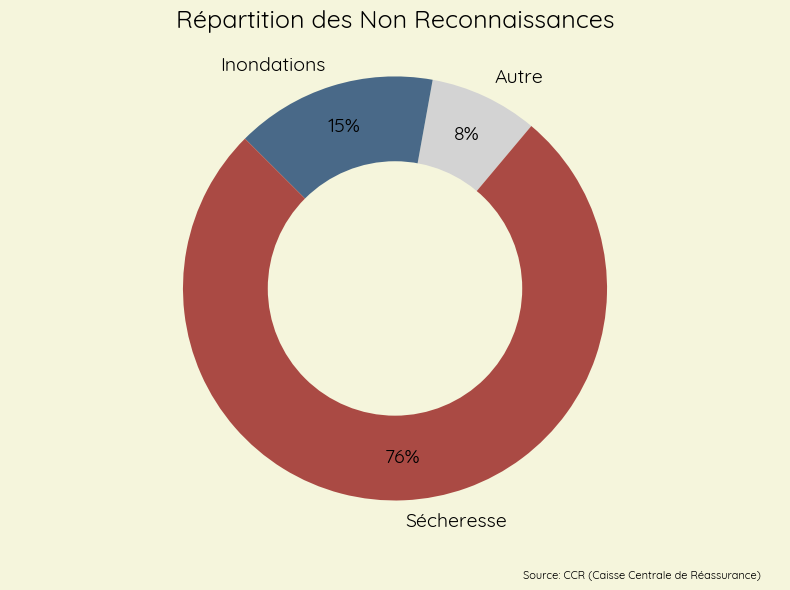

In [80]:
def donut_specific(df, 
                   target_col="libelleAvis",
                   colors=['lightgrey', '#496988', '#AA4A44']):

    df_plot = df.copy()

    if target_col == "libelleAvis":
        title = "Répartition des Non Reconnaissances"
        df_plot = df_plot[df_plot["libelleAvis"] == "Non reconnue"]
    else:
        df_plot = df_plot[(df_plot[target_col] != "Simple") & (df_plot["libelleAvis"] == "Reconnue")]
        title = "Répartition des Franchises 'Doublée ou plus'"


    counts = df_plot.groupby("nomPeril").size()
    sizes = counts.values
    labels_ = counts.index

    fig, ax = plt.subplots(figsize=(8, 6))

    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels_, 
        colors=colors, 
        autopct='%1.0f%%', 
        startangle=50, 
        pctdistance=0.80, 
        textprops={"color": "black", "fontsize": 14}
    )

    centre_circle = plt.Circle((0,0), 0.6, fc='#F5F5DC')
    ax.add_artist(centre_circle)

    ax.axis('equal') 
    ax.set_title(title, 
                 fontsize=18, color="black", pad=20)

    plt.text(
            0.975,
            -0.125,
            source_text,
            ha="right",
            va="bottom",
            transform=ax.transAxes,
            fontsize=8,
            color="black",
        )

    plt.tight_layout()

    return ax

donut_specific(df=details_par_catnat, target_col="libelleAvis");

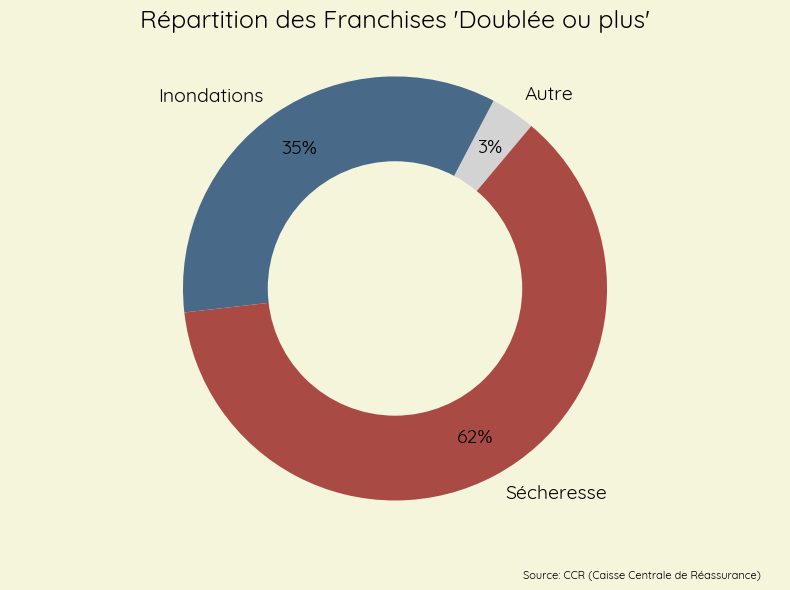

In [79]:
donut_specific(df=details_par_catnat, target_col="franchise");

### STACKED AREA PAR CATNAT

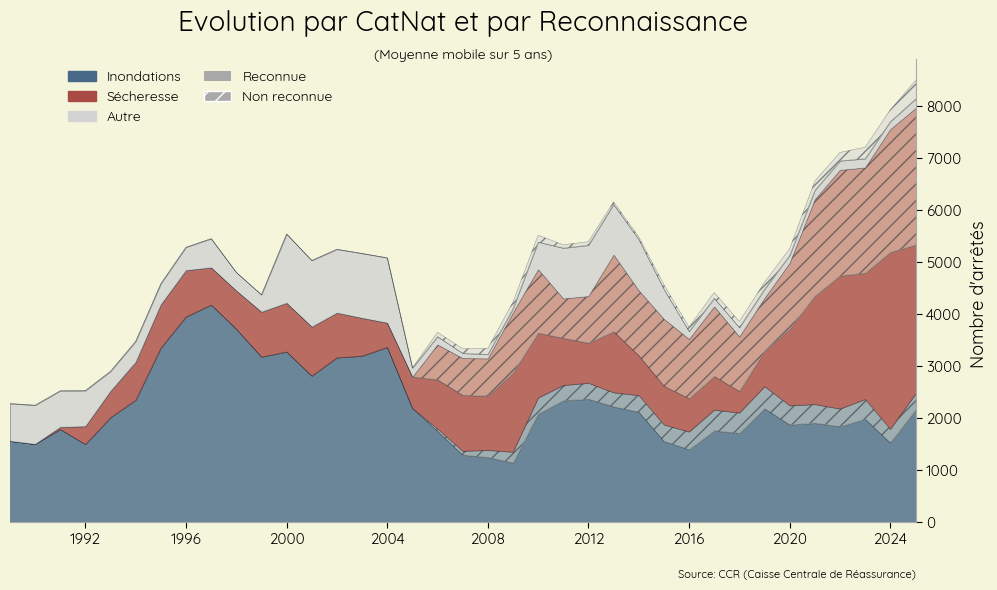

In [81]:
def stacked_area_type_catnat(df, 
                             font=None, 
                             target_col="libelleAvis",
                             hatch='//',
                             limit_years=[1984, 2025],
                             window=3):

    df_plot = df.copy()
    if target_col == "libelleAvis":
        title = "Evolution par CatNat et par Reconnaissance"
        status_request = 'Non reconnue'

        custom_order = ['Reconnue,Inondations', 'Non reconnue,Inondations',
                        'Reconnue,Sécheresse', 'Non reconnue,Sécheresse',
                        'Reconnue,Autre', 'Non reconnue,Autre']
    else:
        df_plot['franchise'] = np.where(
                                        df_plot['franchise'] == 'Simple', 
                                        'Simple', 
                                        'Doublée ou plus'
                                        )
        title = "Evolution par CatNat et par Franchise"
        status_request = 'Doublée ou plus'

        custom_order = ['Simple,Inondations', 'Doublée ou plus,Inondations',
                        'Simple,Sécheresse', 'Doublée ou plus,Sécheresse',
                        'Simple,Autre', 'Doublée ou plus,Autre']

    df_plot = df.pivot_table(
        index='dateArrete', 
        columns=[target_col, 'nomPeril'],
        values='count', 
        aggfunc='sum'
    ).fillna(0)

    df_plot = df_plot.rolling(window=window, center=False).mean()



    new_columns = [(c.split(",")[0], c.split(",")[1]) for c in custom_order]
    df_plot = df_plot[new_columns]

    _, ax = plt.subplots(figsize=(10, 6))

    x = df_plot.index
    y_values = [df_plot[col] for col in df_plot.columns]
    labels = [f"{p} ({s})" for s, p in df_plot.columns]

    layers = ax.stackplot(x, y_values, 
                             labels=labels, 
                             alpha=0.8, 
                             colors=["#496988", "#496988", "#AA4A44", "#AA4A44", "lightgrey", "lightgrey"],
                             edgecolor="#19242E",
                             linewidth=0.3)

    for i, (status, peril) in enumerate(df_plot.columns):
        if status == status_request:
            layers[i].set_hatch(hatch)
            layers[i].set_alpha(0.5)

    peril_handles = [
        mpatches.Patch(color="#496988", label='Inondations'),
        mpatches.Patch(color="#AA4A44", label='Sécheresse'),
        mpatches.Patch(color="lightgrey", label='Autre')
    ]

    status_handles = [
        mpatches.Patch(facecolor='darkgrey', label='Reconnue' if target_col == "libelleAvis" else "Simple"),
        mpatches.Patch(facecolor='darkgrey', hatch=hatch, edgecolor='white', label='Non reconnue' if target_col == "libelleAvis" else "Doublée ou plus")
    ]

    legend_peril = ax.legend(handles=peril_handles, loc='upper left', 
                                bbox_to_anchor=(0.05, 1), title="", 
                                prop=font,
                                fontsize=10, labelcolor='black',
                                frameon=False)
    ax.add_artist(legend_peril)

    ax.legend(handles=status_handles, loc='upper left', 
                 bbox_to_anchor=(0.2, 1), title="",
                 prop=font,
                 fontsize=10, labelcolor='black',
                 frameon=False)
    ax.grid(False)

    plt.title(title, font=font, fontsize=20, color="black", pad=20)
    plt.text(
        0.5,
        1.0,
        f"(Moyenne mobile sur {window} ans)",
        font=font,
        fontsize=10,
        color="black",
        ha="center",
        transform=ax.transAxes,
    ) 

    ax.yaxis.set_ticks_position('right')
    ax.yaxis.set_label_position('right')

    ax.set_ylabel("Nombre d'arrêtés", font=font, fontsize=13, color="black")
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(False)

    ax.yaxis.set_label_coords(1.06, 0.65)


    plt.yticks(font=font, fontsize=11)
    plt.xticks(font=font, fontsize=11)

    plt.text(
        1,
        -0.125,
        source_text,
        ha="right",
        va="bottom",
        transform=ax.transAxes,
        fontsize=8,
        color="black",
        font=font,
    )

    x_start = pd.to_datetime(str(limit_years[0]+window))
    x_end = pd.to_datetime(str(limit_years[1]))
    plt.xlim([x_start, x_end])
    plt.tight_layout()

    return ax

stacked_area_type_catnat(df=avis_par_catnat, window=5);

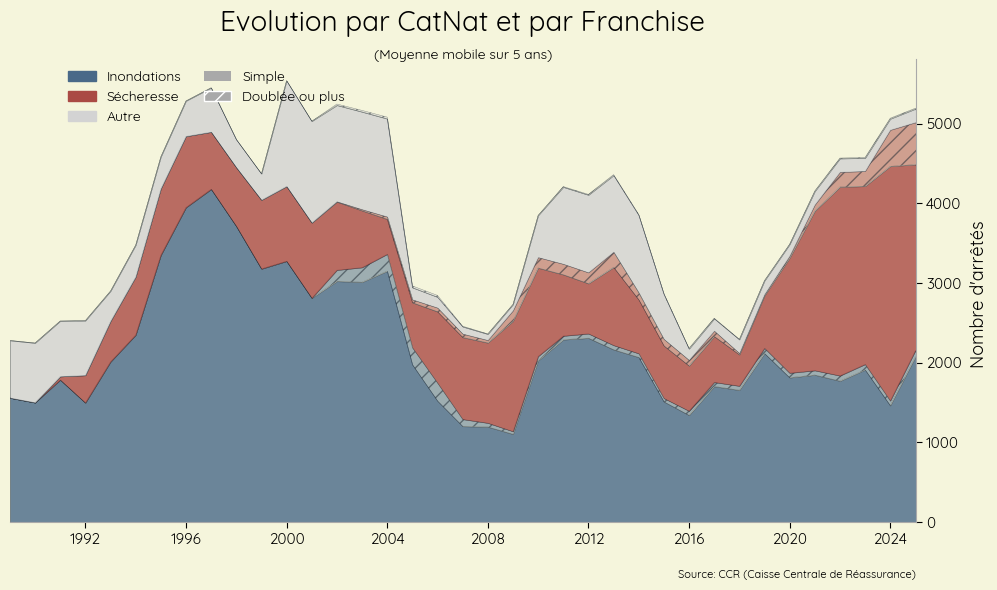

In [84]:
stacked_area_type_catnat(df=franchise_par_catnat, target_col="franchise", window=5);

### BAR PLOT PROGRESSION GLOBALE

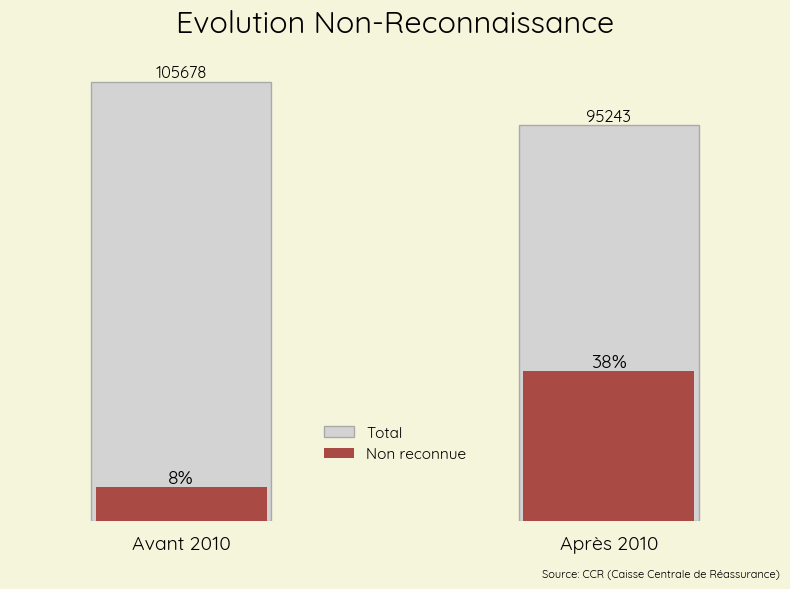

In [85]:
def bar_total_evolution(df,
                        title="Evolution Non-Reconnaissance",
                        filter_col="libelleAvis", 
                        split_year=2010,
                        font=None):

    split_period = f'periode_{split_year}'
    if filter_col == "libelleAvis":
        target_col = "Non reconnue"
    else:
        target_col = "Doublée ou plus"

    total_per_period = df.groupby(split_period)['count'].sum().reset_index()

    non_rec_per_period = df[df[filter_col] == target_col]\
                        .groupby(split_period)['count'].sum().reset_index()

    plot_df = total_per_period.rename(columns={'count': 'Total'}).merge(
        non_rec_per_period.rename(columns={'count': target_col}), on=split_period, how='left'
    ).fillna(0)

    plot_df = plot_df.sort_values(target_col)

    pct_labels = [f"{(non / tot * 100):.0f}%" if tot > 0 else "0%" 
                  for non, tot in zip(plot_df[target_col], plot_df['Total'])]

    fig, ax = plt.subplots(figsize=(8, 6))

    bar_total = ax.bar(plot_df[split_period], plot_df['Total'], 
                        color='lightgrey', 
                        label='Total', 
                        edgecolor='darkgrey',
                        linewidth=1,
                        width=0.42)

    bar_non = ax.bar(plot_df[split_period], 
                      plot_df[target_col], 
                      color='#AA4A44', 
                      label=target_col,
                      linewidth=1,
                      width=0.4)

    ax.bar_label(bar_total, padding=1, 
                 fontproperties=font, 
                 fontsize=12, 
                 color='black',
                 fontweight='bold')

    ax.bar_label(bar_non, labels=pct_labels, 
                 label_type='edge', 
                 fontproperties=font,
                 color='black', 
                 fontsize=14, 
                 fontweight='bold')

    plt.title(title, fontproperties=font, fontsize=22, pad=20, color="black")
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_xlabel("")

    plt.legend(frameon=False, loc='lower center', 
               bbox_to_anchor=(0.5, 0.1), 
               prop=font,
               fontsize=11, 
               labelcolor='black')

    plt.text(
            1,
            -0.125,
            source_text,
            ha="right",
            va="bottom",
            transform=ax.transAxes,
            fontsize=8,
            color="black",
            font=font,
        )

    ax.grid(False)
    ax.set_xlim(-0.4, 1.4)
    ax.tick_params(axis='both', which='both', length=0)

    plt.xticks(font=font, fontsize=14)
    ax.tick_params(axis='x', pad=10)

    plt.tight_layout()

    return ax

bar_total_evolution(df=avis_par_catnat);

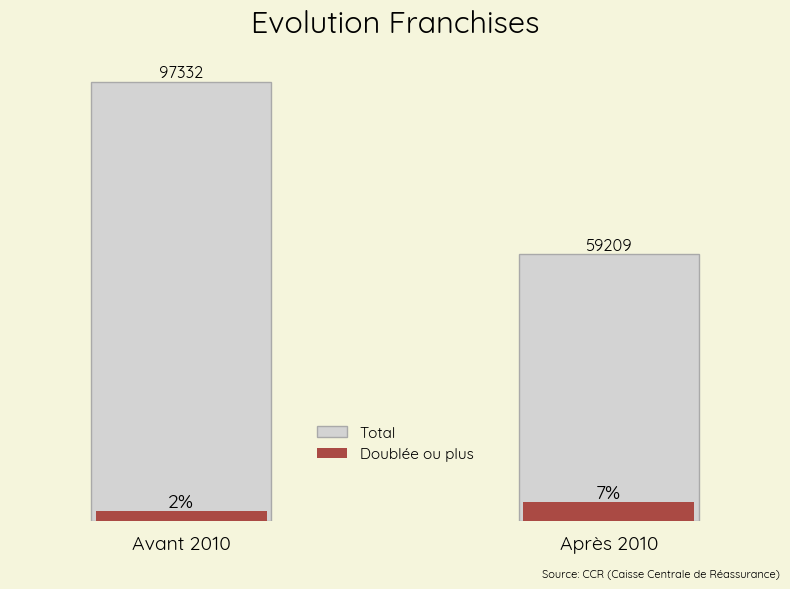

In [86]:
bar_total_evolution(franchise_par_catnat,
                    title="Evolution Franchises",
                    filter_col="franchise", 
                    split_year=2010,
                    font=None);

### BAR PLOT PROGRESSION PAR CATNAT

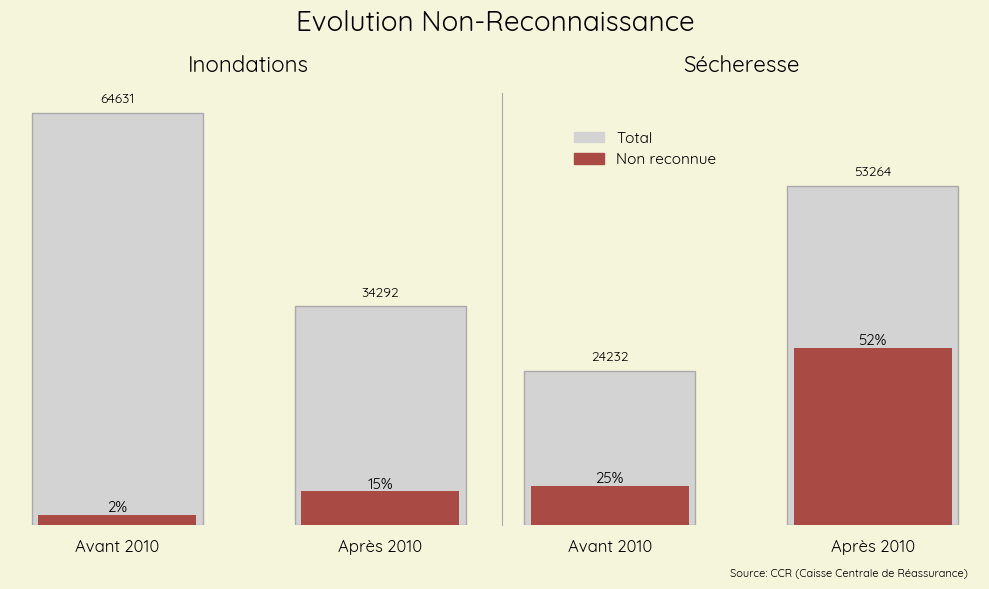

In [88]:
def bar_catnat_evolution(df,
                         target_col="libelleAvis",
                         perils=["Inondations", "Sécheresse"],
                         split_year=2010):

    split_period = f'periode_{split_year}'

    if target_col == "libelleAvis":
        select_cols = ["Non reconnue", "Reconnue"]
        title="Evolution Non-Reconnaissance"
    else:
        select_cols = ["Doublée ou plus", "Simple"]
        title="Evolution des Franchises"

    df_filtered = df[df["nomPeril"].isin(perils)]
    df_plot = df_filtered.groupby(['nomPeril', split_period, target_col])['count'].sum().unstack(fill_value=0)
    df_plot['Total'] = df_plot[select_cols[0]] + df_plot[select_cols[1]]
    df_plot = df_plot.reset_index()
    df_plot = df_plot.sort_values(select_cols[0])

    fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

    for i, peril in enumerate(perils):
        ax = axes[i]
        data = df_plot[df_plot['nomPeril'] == peril]

        bar_tot = ax.bar(data[split_period], data['Total'], 
                         color='lightgrey', 
                          edgecolor='darkgrey', width=0.65)

        bar_non = ax.bar(data[split_period], data[select_cols[0]], 
                         color='#AA4A44', linewidth=1.5, width=0.6)

        ax.bar_label(bar_tot, padding=5, fontsize=10, fontweight='bold', color="black")

        pcts = [f"{(n/t*100):.0f}%" if t > 0 else "0%" for n, t in zip(data[select_cols[0]], data['Total'])]
        ax.bar_label(bar_non, labels=pcts, label_type='edge',
                      color='black', fontsize=11, fontweight='bold')

        ax.set_title(peril, fontsize=16, pad=15, color="black")
        ax.tick_params(axis='x', which='both', length=0, pad=10, labelsize=12)

        ax.spines[['top', 'right', 'bottom'] if peril == "Sécheresse" else ['top', 'right', "left", 'bottom']].set_visible(False)
        ax.yaxis.set_visible(False)

        ax.grid(False)

    handles = [plt.Rectangle((0,0),1,1, color='lightgrey'), 
               plt.Rectangle((0,0),1,1, color='#AA4A44')]
    fig.legend(handles, ['Total', select_cols[0]], 
               loc='upper center', bbox_to_anchor=(0.65, 0.8), 
               ncol=1, 
               frameon=False,
               fontsize=11, 
               labelcolor='black')

    plt.text(
            0.975,
            -0.125,
            source_text,
            ha="right",
            va="bottom",
            transform=ax.transAxes,
            fontsize=8,
            color="black",
        )

    plt.suptitle(title, fontsize=20, color="black")

    plt.tight_layout()

    return fig

bar_catnat_evolution(df=avis_par_catnat);

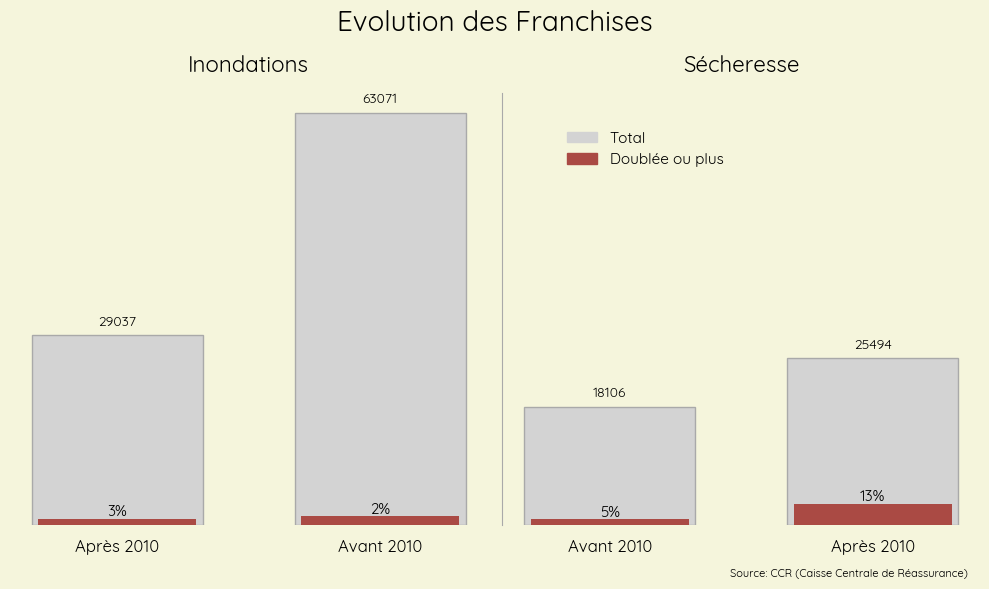

In [90]:
bar_catnat_evolution(df=franchise_par_catnat, target_col="franchise");

### TAUX DE RECO & PENALITÉ

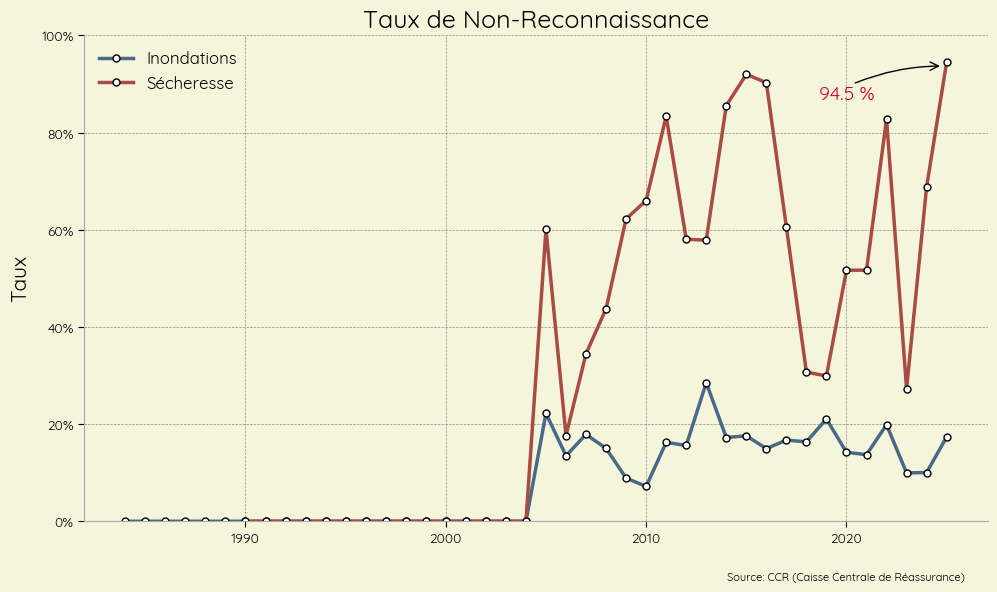

In [91]:
def taux_catnat_ts(df, 
                   target_col="libelleAvis"):

    if target_col == "libelleAvis":
        select_cols = ["Non reconnue", "Reconnue"]
        title="Taux de Non-Reconnaissance"
    else:
        select_cols = ["Doublée ou plus", "Simple"]
        title="Taux de Franchises 'Doublée ou plus'"

    df_plot = df[df["nomPeril"] != "Autre"].pivot_table(
        index=['dateArrete', 'nomPeril'], 
        columns=target_col, 
        values='count', 
        fill_value=0
    ).reset_index()

    df_plot['ratio'] = df_plot[select_cols[0]] / (df_plot[select_cols[0]] + df_plot[select_cols[1]])
    df_plot['ratio'] = df_plot['ratio']\
        .replace([np.inf, -np.inf], np.nan).fillna(0)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=df_plot, 
        x=df_plot['dateArrete'].dt.year, 
        y='ratio', 
        palette=["#496988", "#AA4A44"],
        marker='o',
        hue='nomPeril',
        linewidth=2.5,
        ms=5,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1,
        ax=ax
    )

    plt.title(title, 
              fontsize=18, color="black")
    plt.ylabel("Taux", fontsize=15, 
               color="black")
    plt.xlabel("")
    plt.grid(True, linestyle='--', alpha=0.7)

    ax.tick_params(labelsize=10)
    ax.yaxis.set_label_coords(-0.06, 0.55)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylim(0.0, 1)

    plt.legend(title="", 
               frameon=False,
               fontsize=12,
               labelcolor="black")

    if target_col == "libelleAvis":
        fig_arrow(
            head_position=(0.94, 0.88),
            tail_position=(0.85, 0.85),
            width=1,
            radius=-0.1,
            color="black",
            fill_head=False,
            mutation_scale=0.75,
        )

        plt.text(
            0.875,
            0.86,
            f"{(df_plot["ratio"].max() * 100).round(1)} %",
            ha="right",
            va="bottom",
            transform=ax.transAxes,
            fontsize=14,
            color="#D2042D",
            fontweight='bold'
        )

        plt.text(
            0.975,
            -0.125,
            source_text,
            ha="right",
            va="bottom",
            transform=ax.transAxes,
            fontsize=8,
            color="black",
        )

    plt.tight_layout()
    return ax

taux_catnat_ts(df=avis_par_catnat);

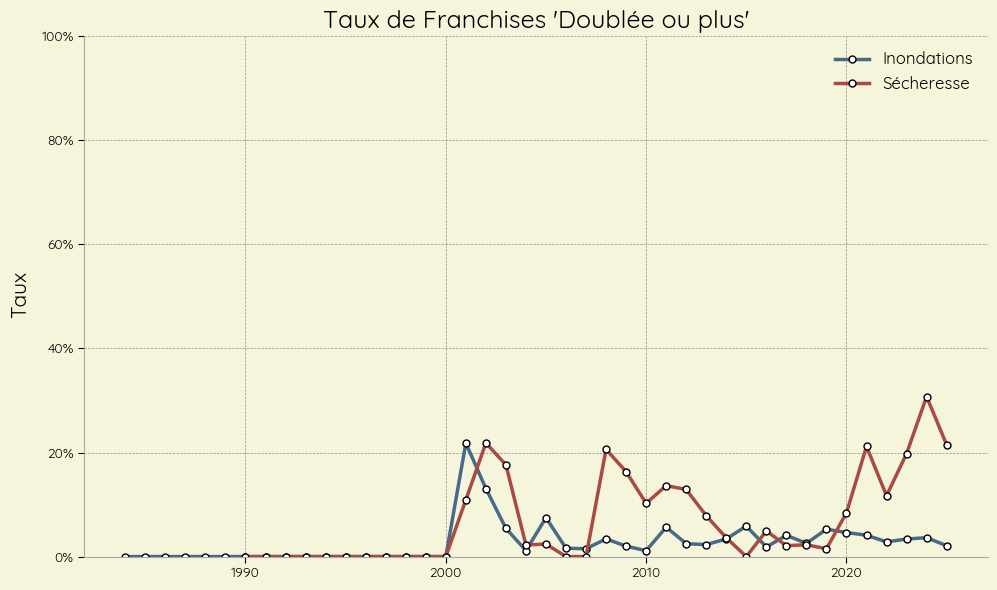

In [93]:
taux_catnat_ts(df=franchise_par_catnat, target_col="franchise");

## __CARTO__

### DATA MANIPULATION

In [95]:
df_map = details_par_catnat.copy()

conditions = [
    df_map["franchise"] == "Simple",
    df_map["franchise"] == "Doublée",
    df_map["franchise"].isin(["Triplée", "Quadruplée"])
]
cat = ["Simple", "Doublée", "Triplée+"]
df_map['f_cat'] = np.select(conditions, cat, default="Autre")
df_map['is_triple_plus'] = df_map['f_cat'] == "Triplée+"

pivot_avis = df_map.pivot_table(
    index="codeInsee",
    columns=["nomPeril", "libelleAvis"],
    values="dateArrete", 
    aggfunc="count",
    fill_value=0
)

df_recognized = df_map[df_map["libelleAvis"] == "Reconnue"]
pivot_franchise = df_recognized.pivot_table(
    index="codeInsee",
    columns=["nomPeril", "f_cat"],
    values="dateArrete",
    aggfunc="count",
    fill_value=0
)

# Global Stats
final_stats = pd.DataFrame(index=pivot_avis.index)

total_non_rec = pivot_avis.xs('Non reconnue', level=1, axis=1, drop_level=False).sum(axis=1)
total_events = pivot_avis.sum(axis=1)
final_stats['taux_non_rec_global'] = (total_non_rec / total_events.replace(0, 1) * 100).fillna(0)
final_stats['num_total'] = total_events 

total_penalized = (
    pivot_franchise.xs('Doublée', level=1, axis=1, drop_level=False).sum(axis=1) + 
    pivot_franchise.xs('Triplée+', level=1, axis=1, drop_level=False).sum(axis=1)
)
total_rec_events = pivot_franchise.sum(axis=1)

final_stats['taux_penalite_global'] = (total_penalized / total_rec_events.replace(0, 1) * 100).fillna(0)
final_stats['num_reconnue_total'] = total_rec_events

final_stats['num_triple_plus_global'] = pivot_franchise.xs('Triplée+', level=1, axis=1, drop_level=False).sum(axis=1)

# Peril-Specific Stats
perils = ['Inondations', 'Sécheresse', 'Autre']
for peril in perils:
    # Non-Reconnaissance
    try:
        n_rec = pivot_avis.get((peril, 'Non reconnue'), 0)
        n_ok = pivot_avis.get((peril, 'Reconnue'), 0)
        total_p = n_rec + n_ok

        final_stats[f'num_{peril.lower()}'] = total_p
        final_stats[f'taux_non_rec_{peril.lower()}'] = (n_rec / total_p * 100).fillna(0)
    except KeyError:
        final_stats[f'num_{peril.lower()}'] = 0
        final_stats[f'taux_non_rec_{peril.lower()}'] = 0

    # Franchises
    try:
        f_simple = pivot_franchise.get((peril, 'Simple'), 0)
        f_double = pivot_franchise.get((peril, 'Doublée'), 0)
        f_triple = pivot_franchise.get((peril, 'Triplée+'), 0)
    
        total_f = f_simple + f_double + f_triple
        final_stats[f'taux_penalite_{peril.lower()}'] = ((f_double + f_triple) / total_f * 100).fillna(0)
        final_stats[f'num_triple_plus_{peril.lower()}'] = f_triple
    
    except KeyError:
        final_stats[f'taux_penalite_{peril.lower()}'] = 0
        final_stats[f'num_triple_plus_{peril.lower()}'] = 0

communes_geo_taux = communes_geo.merge(
    final_stats, 
    left_on="code", 
    right_index=True, 
    how="left"
).fillna(0)

communes_geo_taux.head(2)

,code,nom,geometry,taux_non_rec_global,num_total,taux_penalite_global,num_reconnue_total,num_triple_plus_global,num_inondations,taux_non_rec_inondations,taux_penalite_inondations,num_triple_plus_inondations,num_sécheresse,taux_non_rec_sécheresse,taux_penalite_sécheresse,num_triple_plus_sécheresse,num_autre,taux_non_rec_autre,taux_penalite_autre,num_triple_plus_autre
0,97101,Abymes,"MULTIPOLYGON (((-61.54884 16.25312, -61.54687 ...",19.047619,21.0,0.0,17.0,0.0,12.0,8.333333,0.0,0.0,0.0,0.0,0.0,0.0,9.0,33.333333,0.0,0.0
1,97102,Anse-Bertrand,"POLYGON ((-61.43453 16.43901, -61.43465 16.441...",46.153846,13.0,0.0,7.0,0.0,5.0,40.000000,0.0,0.0,0.0,0.0,0.0,0.0,8.0,50.000000,0.0,0.0


In [97]:
def growth_analysis(df, split_year=2010, end_year=2025):
    df = df.copy()

    df['year'] = pd.to_datetime(df['dateArrete']).dt.year
    df['period'] = np.where(df['year'] < split_year, 'pre', 'recent')

    if 'f_cat' not in df.columns:
        conditions = [
            df["franchise"] == "Simple",
            df["franchise"].isin(["Doublée", "Triplée", "Quadruplée", "Doublée+"]) 
        ]
    
        choices = ["Simple", "Doublée+"]
    
        df['f_cat'] = np.select(conditions, choices, default="Inconnu")

    years_pre = split_year - 1982
    years_recent = end_year - split_year

    stats = df.groupby(['codeInsee', 'period']).agg(
        total_events=('libelleAvis', 'count'),
        refusals=('libelleAvis', lambda x: (x == "Non reconnue").sum()),
        recognitions=('libelleAvis', lambda x: (x == "Reconnue").sum()),
        doubled_penalties=('f_cat', lambda x: (x == "Doublée+").sum())
    ).unstack(fill_value=0)

    stats['freq_pre'] = stats[('total_events', 'pre')] / years_pre
    stats['freq_recent'] = stats[('total_events', 'recent')] / years_recent
    stats['freq_growth'] = ((stats['freq_recent'] - stats['freq_pre']) / (stats['freq_pre'] + 0.01)) * 100

    stats['taux_non_rec_pre'] = (stats[('refusals', 'pre')] / stats[('total_events', 'pre')].replace(0, 1)) * 100
    stats['taux_non_rec_recent'] = (stats[('refusals', 'recent')] / stats[('total_events', 'recent')].replace(0, 1)) * 100
    stats['taux_non_rec_growth'] = stats['taux_non_rec_recent'] - stats['taux_non_rec_pre']

    stats['taux_penalite_pre'] = (stats[('doubled_penalties', 'pre')] / stats[('recognitions', 'pre')].replace(0, 1)) * 100
    stats['taux_penalite_recent'] = (stats[('doubled_penalties', 'recent')] / stats[('recognitions', 'recent')].replace(0, 1)) * 100
    stats['taux_penalite_growth'] = stats['taux_penalite_recent'] - stats['taux_penalite_pre']

    stats.columns = [f"{col[0]}_{col[1]}"[:-1] if isinstance(col, tuple) else col for col in stats.columns]

    keep_cols = [
        "freq_pre", "freq_recent", "freq_growth",
        "taux_non_rec_pre", "taux_non_rec_recent", "taux_non_rec_growth",
        "taux_penalite_pre", "taux_penalite_recent", "taux_penalite_growth"
    ]

    return stats[keep_cols]

communes_geo_growth = growth_analysis(details_par_catnat)
communes_geo_growth.head(2)

,freq_pre,freq_recent,freq_growth,taux_non_rec_pre,taux_non_rec_recent,taux_non_rec_growth,taux_penalite_pre,taux_penalite_recent,taux_penalite_growth
codeInsee,,,,,,,,,
01001,0.071429,0.000000,-87.719298,0.0,0.0,0.0,0.0,0.0,0.0
01002,0.071429,0.000000,-87.719298,0.0,0.0,0.0,0.0,0.0,0.0
01004,0.107143,0.533333,363.821138,0.0,37.5,37.5,0.0,40.0,40.0
01005,0.035714,0.000000,-78.125000,0.0,0.0,0.0,0.0,0.0,0.0
01006,0.035714,0.000000,-78.125000,0.0,0.0,0.0,0.0,0.0,0.0


In [103]:
# Final dataset
communes_geo_params = communes_geo_taux.merge(communes_geo_growth, left_on="code", right_on = "codeInsee", how="left")
mask = (communes_geo_params["num_total"] > 2) & (communes_geo_params["num_reconnue_total"] > 1)
communes_geo_params = communes_geo_params[mask]
communes_geo_params.head(2)

,code,nom,geometry,taux_non_rec_global,num_total,taux_penalite_global,num_reconnue_total,num_triple_plus_global,num_inondations,taux_non_rec_inondations,...,num_triple_plus_autre,freq_pre,freq_recent,freq_growth,taux_non_rec_pre,taux_non_rec_recent,taux_non_rec_growth,taux_penalite_pre,taux_penalite_recent,taux_penalite_growth
0,97101,Abymes,"MULTIPOLYGON (((-61.54884 16.25312, -61.54687 ...",19.047619,21.0,0.0,17.0,0.0,12.0,8.333333,...,0.0,0.321429,0.8,144.396552,22.222222,16.666667,-5.555556,0.0,0.0,0.0
1,97102,Anse-Bertrand,"POLYGON ((-61.43453 16.43901, -61.43465 16.441...",46.153846,13.0,0.0,7.0,0.0,5.0,40.000000,...,0.0,0.250000,0.4,57.692308,28.571429,66.666667,38.095238,0.0,0.0,0.0


### MONOVARIATE MAP

In [100]:
def prepare_france_geometry(df):
    if df.crs != "EPSG:2154":
        df = df.to_crs(epsg=2154)

    df['dept_temp'] = df['code'].apply(lambda x: x[:3] if x.startswith('97') else x[:2])

    drom_configs = {
        '971': {'pos': (-150000, 6540000), 'scale': 1.3, 'name': "Guadeloupe"},
        '972': {'pos': (50000, 6540000),   'scale': 1.8, 'name': "Martinique"},
        '973': {'pos': (-150000, 6140000), 'scale': 0.25, 'name': "Guyane"},
        '974': {'pos': (-150000, 6340000), 'scale': 1, 'name': "La Réunion"},
        '976': {'pos': (50000, 6340000),   'scale': 2.5, 'name': "Mayotte"},
    }

    df_main = df[~df['dept_temp'].str.startswith('97')].copy()
    df_droms = []

    for code, cfg in drom_configs.items():
        drom = df[df['dept_temp'] == code].copy()
        if not drom.empty:
            centroid = drom.geometry.unary_union.centroid
            drom.geometry = drom.geometry.translate(xoff=-centroid.x, yoff=-centroid.y)
            drom.geometry = drom.geometry.scale(xfact=cfg['scale'], yfact=cfg['scale'], origin=(0,0))

            # Box Position
            drom.geometry = drom.geometry.translate(xoff=cfg['pos'][0], yoff=cfg['pos'][1])
            df_droms.append(drom)

    return gpd.pd.concat([df_main] + df_droms), drom_configs

def monovariate_map(df, col="taux_non_rec_global", cmap="copper_r", 
                    title="Taux de non-reconnaissance par commune", 
                    missing_color="white", norm=None, 
                    legend_label="(%)",
                    subtitle=None, linewidth=0.1, colorbar=True):

    df_plot, drom_configs = prepare_france_geometry(df)

    fig, ax = plt.subplots(figsize=(14, 12))

    df_plot.plot(
        ax=ax,
        column=col,
        cmap=cmap,
        norm=norm,
        legend=colorbar,
        legend_kwds={"shrink": 0.4, "pad": -0.05},
        missing_kwds={"color": missing_color, "edgecolor": "black"},
        edgecolor="black",
        linewidth=linewidth, 
    )

    cbar_ax = ax.get_figure().get_axes()[-1]
    cbar_ax.set_ylabel(f" {legend_label}", color="black")

    if subtitle:
        ax.text(0.5, 0.99, subtitle, transform=ax.transAxes, 
                fontsize=14, color='dimgray', ha='center', style='italic')

    # Box size (width, height) in meters
    box_w, box_h = 180000, 150000 

    for code, cfg in drom_configs.items():
        x, y = cfg['pos']
        rect = mpatches.Rectangle(
            (x - box_w/2, y - box_h/2), box_w, box_h,
            linewidth=0.5, edgecolor='gray', facecolor='none', 
            linestyle='--', alpha=0.6
        )
        ax.add_patch(rect)

        # Add label above each box
        ax.text(x, y + (box_h/2) + 12500, cfg['name'], 
                fontsize=9, ha='center', color='dimgray')

    ax.set_axis_off()
    ax.set_title(title, fontsize=22, fontweight='bold', pad=15, color="black")

    null_patch = mpatches.Patch(color=missing_color, label="Pas de cas", edgecolor="black")
    leg = ax.legend(handles=[null_patch], loc="lower left", frameon=False, bbox_to_anchor=(0.5, 0.025))

    plt.setp(leg.get_texts(), color='black', fontsize=10) 

    ax.set_xlim(-280000, 1250000)
    ax.set_ylim(6000000, 7150000)

    return fig

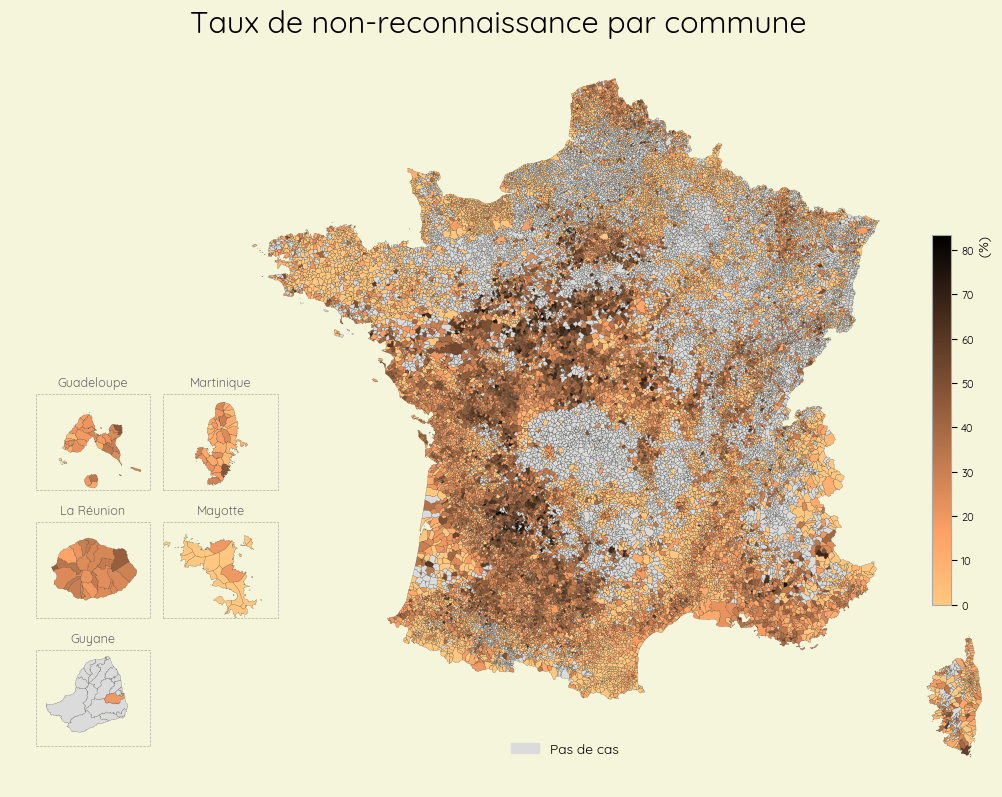

In [105]:
missing_color = "#DBDBDB"
communes_geo_plot = communes_geo.merge(communes_geo_params, how="left") # To display non available data

monovariate_map(communes_geo_plot, missing_color=missing_color);

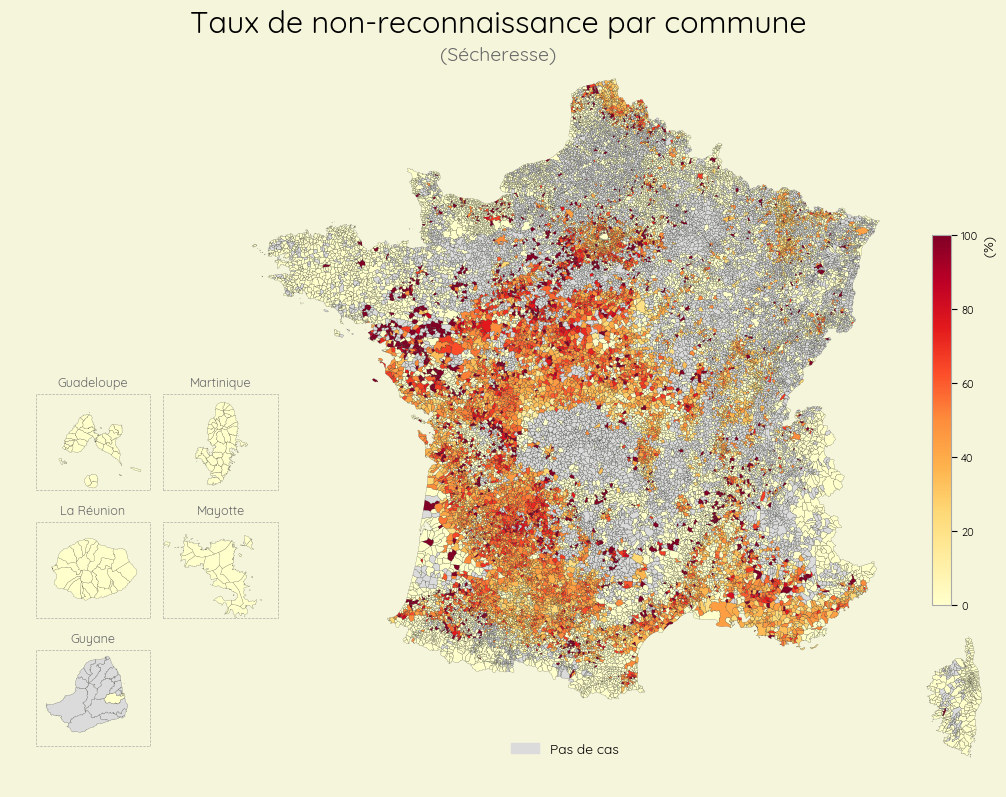

In [106]:
monovariate_map(communes_geo_plot, 
                col="taux_non_rec_sécheresse", 
                cmap="YlOrRd",
                title="Taux de non-reconnaissance par commune",
                subtitle="(Sécheresse)",
                missing_color=missing_color);

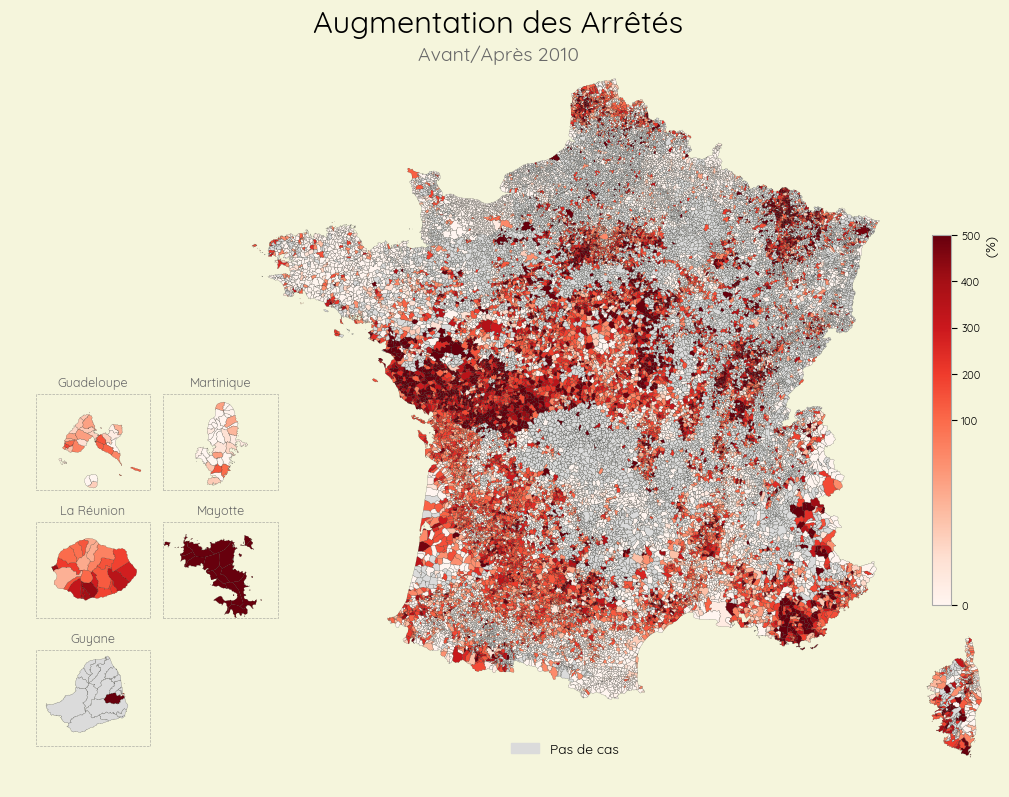

In [107]:
vmin, vmax, vcenter = 0, 500, 100
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

monovariate_map(communes_geo_plot, 
                col="freq_growth", 
                cmap="Reds",
                norm=norm,
                title="Augmentation des Arrêtés", 
                missing_color=missing_color,
                subtitle="Avant/Après 2010");

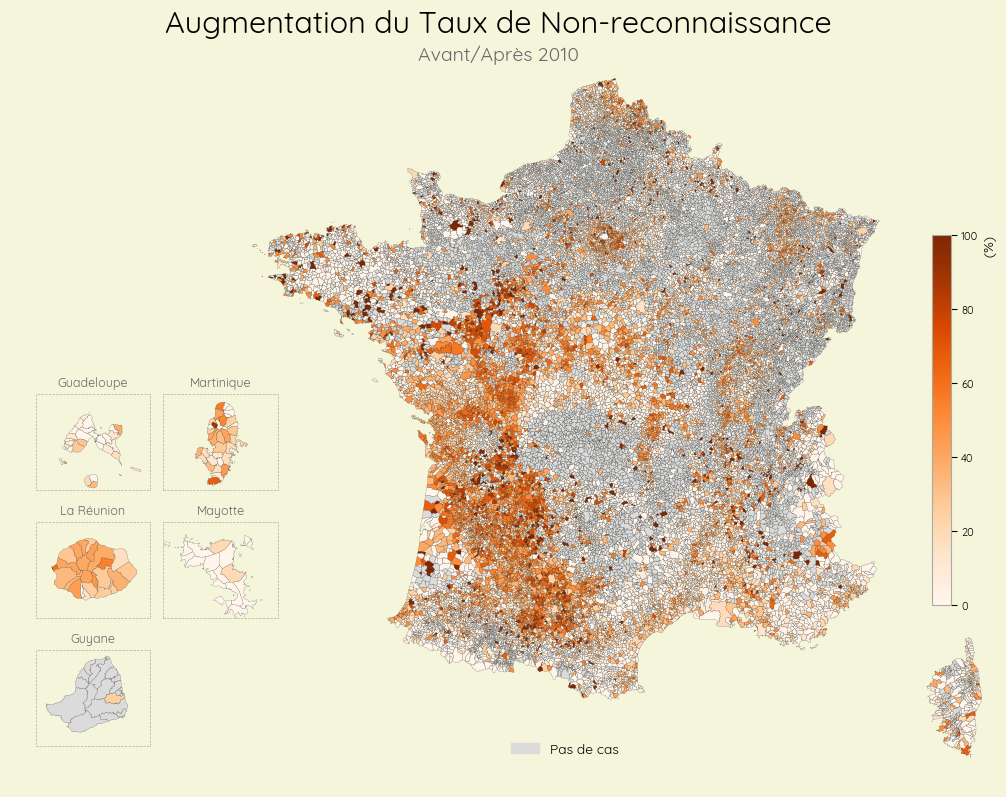

In [109]:
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=50, vmax=100)

monovariate_map(communes_geo_plot, 
                col="taux_non_rec_growth", 
                cmap="Oranges",
                norm=norm,
                title="Augmentation du Taux de Non-reconnaissance", 
                missing_color=missing_color,
                subtitle="Avant/Après 2010");

#### COMMUNES CRITIQUES 
25% Distribution:
- __freq_growth__
- __taux_non_rec_growth__
- __num_triple_plus_global__

In [113]:
df_quant = communes_geo_plot.copy()

quant = 3
labels = np.arange(1,quant+1)
cols = ["freq_growth", "taux_non_rec_growth", "taux_penalite_growth", "num_triple_plus_global"]
for col in cols:
    df_quant[col] = (df_quant[col] -  df_quant[col].min())/(df_quant[col].max() -  df_quant[col].min())
    df_quant[f"{col}_class"] = pd.qcut(
            df_quant[col].rank(method='first'), 
            [0, 0.25, 0.5, 0.85], # 85%
            labels=labels
        )

triple_high_mask = (
    (df_quant["freq_growth_class"] == quant) & 
    (df_quant["taux_non_rec_growth_class"] == quant) & 
    (df_quant["num_triple_plus_global_class"] == quant)
    #(df_quant["taux_penalite_growth_class"] == quant)
)

critical_communes = df_quant[triple_high_mask]
critical_communes = critical_communes.groupby(["code"]).size()
critical_communes = critical_communes.reset_index()

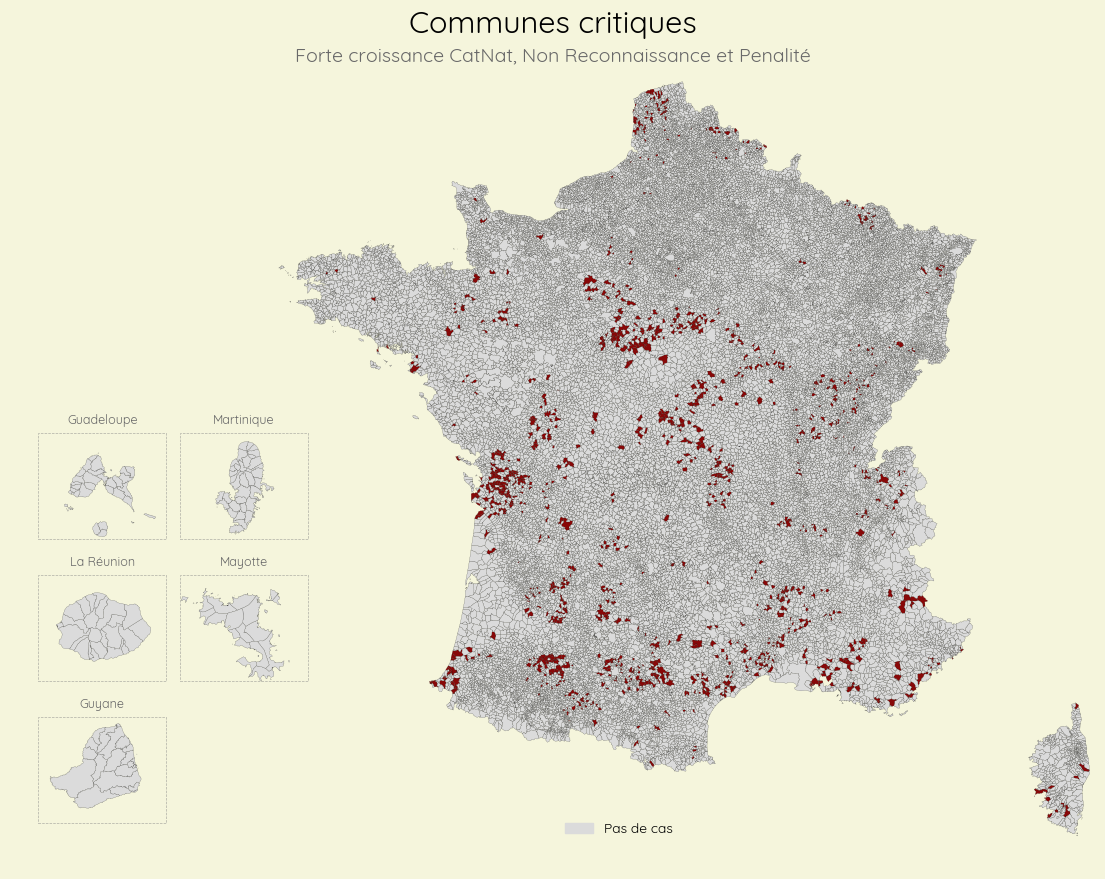

In [114]:
monovariate_map(communes_geo.merge(critical_communes, on="code", how="left"), 
                col=0, 
                cmap=LinearSegmentedColormap.from_list("monochrome", ["#880808", "#880808"]),
                title="Communes critiques", 
                subtitle="Forte croissance CatNat, Non Reconnaissance et Penalité",
                missing_color=missing_color,
                colorbar=False);

### BIVARIATE MAPS

In [125]:
def bivariate_map(df, 
                  cols=["taux_global", "num_total"],
                  quants=[[0.7, 0.9],[0.5, 0.85]], # Not in use => with pd.qcut [0, 0.33, 0.66]
                  title="Bivariée: Nombre CatNat et Non Reconnaissance",
                  legend_labels=["Non-reconnaissance", "N CatNat"],
                  colors=[
                        "#e8e8e8",
                        "#b0d5df",
                        "#64acbe",
                        "#e4acac",
                        "#ad9ea5",
                        "#627f8c",
                        "#c85a5a",
                        "#985356",
                        "#574249",
                    ],
                    subtitle=None,
                    focus=False):

    df_plot = df.copy()
    df_plot, drom_configs = prepare_france_geometry(df_plot)

    # Norm & Quantile (Not in use) [Modify this function]
    #percentiles = []
    for col, quant in zip(cols, quants):
        df_plot[col] = (df_plot[col] -  df_plot[col].min())/(df_plot[col].max() -  df_plot[col].min())
        #perc = df_plot[col].quantile(quant)
        #percentiles.extend(perc.values)

    #bins_var1 = [0, percentiles[0], percentiles[1], 1]
    #bins_var2 = [0, percentiles[2], percentiles[3], 1]

    df_plot["Var1_Class"] = pd.qcut(
        df_plot[cols[0]].rank(method='first'),
        3
    )
    df_plot["Var1_Class"] = df_plot["Var1_Class"].astype("str")

    df_plot["Var2_Class"] = pd.qcut(
        df_plot[cols[1]].rank(method='first'), 
        3
    )

    df_plot["Var2_Class"] = df_plot["Var2_Class"].astype("str")

    x_class_codes = np.arange(1, 4)
    d = dict(
        zip(
            df_plot["Var1_Class"].value_counts().sort_index().index,
            x_class_codes,
        )
    )
    df_plot["Var1_Class"] = df_plot["Var1_Class"].replace(d)

    # Code created y bins to A, B, C
    y_class_codes = ["A", "B", "C"]
    d = dict(
        zip(
            df_plot["Var2_Class"].value_counts().sort_index().index,
            y_class_codes,
        )
    )
    df_plot["Var2_Class"] = df_plot["Var2_Class"].replace(d)

    # Combine x and y codes to create Bi_Class
    df_plot["Bi_Class"] = (
        df_plot["Var1_Class"].astype("str") + df_plot["Var2_Class"]
    )

    cmap = matplotlib.colors.ListedColormap(colors)

    # MAIN PLOT
    fig, ax = plt.subplots(figsize=(8, 8))

    df_plot.plot(
        ax=ax,
        column="Bi_Class", 
        cmap=cmap, 
        alpha=0.5 if focus else 1,
        categorical=True, 
        legend=False,
        linewidth=0.1
    )

    plt.tight_layout()
    plt.axis("off")
    ax.set_title(
        title,
        font=font,
        fontsize=20,
        color="black",
    )

    # Box size (width, height) in meters
    box_w, box_h = 180000, 150000 

    for code, cfg in drom_configs.items():
        x, y = cfg['pos']
        rect = mpatches.Rectangle(
            (x - box_w/2, y - box_h/2), box_w, box_h,
            linewidth=0.5, edgecolor='gray', facecolor='none', 
            linestyle='--', alpha=0.6
        )
        ax.add_patch(rect)

        # Add label above each box
        ax.text(x, y + (box_h/2) + 12500, cfg['name'], 
                fontsize=9, ha='center', color='dimgray')

    # FOCUS
    if focus:
        darkest_label = "3C"
        high_high = df_plot[df_plot["Bi_Class"] == darkest_label]

        high_high.plot(
            ax=ax,
            color=colors[8],  # The darkest color (top-right of legend)
            edgecolor="black",
            linewidth=0.1,
            alpha=1.0,
        )

    img2 = fig
    ax2 = fig.add_axes([0.1, 0.675, 0.1, 0.1])

    alpha = 1

    # Column 1
    ax2.axvspan(
        xmin=0, xmax=0.33, ymin=0, ymax=0.33, alpha=alpha, color=colors[0]
    )
    ax2.axvspan(
        xmin=0, xmax=0.33, ymin=0.33, ymax=0.66, alpha=alpha, color=colors[1]
    )
    ax2.axvspan(
        xmin=0, xmax=0.33, ymin=0.66, ymax=1, alpha=alpha, color=colors[2]
    )

    # Column 2
    ax2.axvspan(
        xmin=0.33, xmax=0.66, ymin=0, ymax=0.33, alpha=alpha, color=colors[3]
    )
    ax2.axvspan(
        xmin=0.33, xmax=0.66, ymin=0.33, ymax=0.66, alpha=alpha, color=colors[4]
    )
    ax2.axvspan(
        xmin=0.33, xmax=0.66, ymin=0.66, ymax=1, alpha=alpha, color=colors[5]
    )

    # Column 3
    ax2.axvspan(
        xmin=0.66, xmax=1, ymin=0, ymax=0.33, alpha=alpha, color=colors[6]
    )
    ax2.axvspan(
        xmin=0.66, xmax=1, ymin=0.33, ymax=0.66, alpha=alpha, color=colors[7]
    )
    ax2.axvspan(
        xmin=0.66, xmax=1, ymin=0.66, ymax=1, alpha=alpha, color=colors[8]
    )

    # Annoate the legend
    ax2.tick_params(
        axis="both", which="both", length=0
    )  # remove ticks from the big box
    ax2.axis("off")  # turn off its axis
    ax2.annotate(
        "", xy=(0, 1), xytext=(0, 0), arrowprops=dict(arrowstyle="->", lw=1)
    )  # draw arrow for x
    ax2.annotate(
        "", xy=(1, 0), xytext=(0, 0), arrowprops=dict(arrowstyle="->", lw=1)
    )  # draw arrow for y
    ax2.text(
        s=legend_labels[0], x=0.1, y=-0.25, color="black", fontsize=9
    )  # annotate x axis
    ax2.text(
        s=legend_labels[1], x=-0.25, y=0.1, rotation=90, color="black", fontsize=9
    )  # annotate y axis

    # Highlight indicator on the legend 
    if focus:
        ax2.add_patch(
            plt.Rectangle((0.66, 0.66), 0.34, 0.34, fill=False, edgecolor="black", lw=1)
            )
    
    if subtitle:
        ax.text(0.5, 0.98, subtitle, transform=ax.transAxes, 
                fontsize=14, color='dimgray', ha='center', style='italic')

    return fig

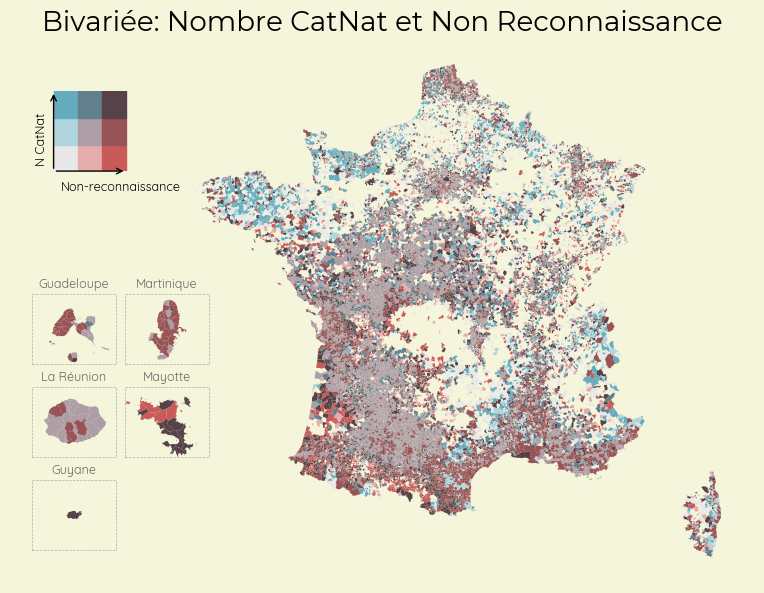

In [126]:
bivariate_map(df=communes_geo_params,
              cols=["taux_non_rec_global", "num_total"],
              focus=False);

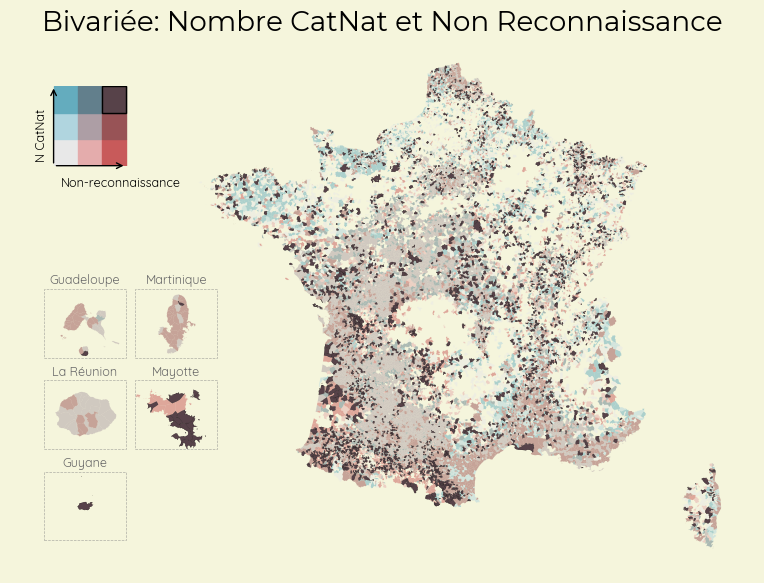

In [127]:
bivariate_map(df=communes_geo_params,
                  cols=["taux_non_rec_global", "num_total"],
                  focus=True);

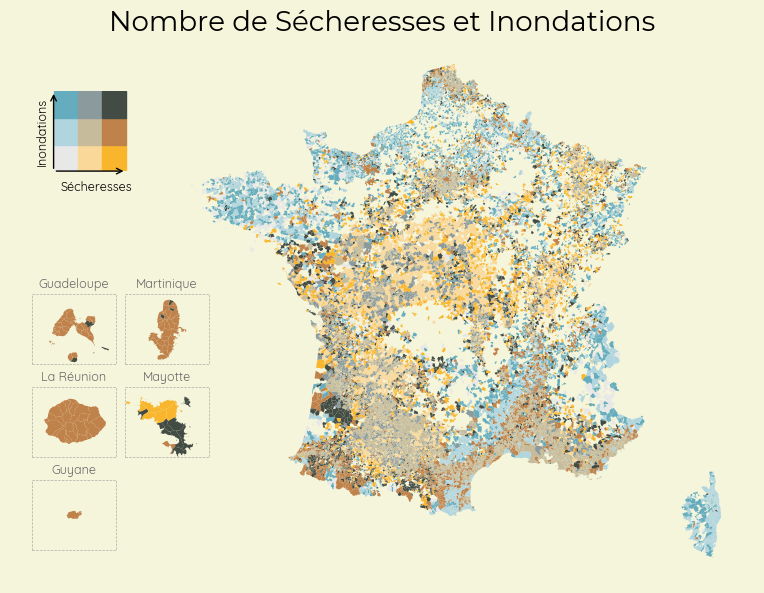

In [128]:
colors_ = [
            "#e8e8e8", 
            "#b0d5df", 
            "#64acbe",
            "#f9d89a", 
            "#c6bc9c", 
            "#8b9a9d", 
            "#f9b62c", 
            "#c0824b", 
            "#434c44", 
        ]

bivariate_map(df=communes_geo_params,
              cols=["num_sécheresse", "num_inondations"],
              title="Nombre de Sécheresses et Inondations",
              legend_labels=["Sécheresses", "Inondations"],
              colors=colors_,
              focus=False);

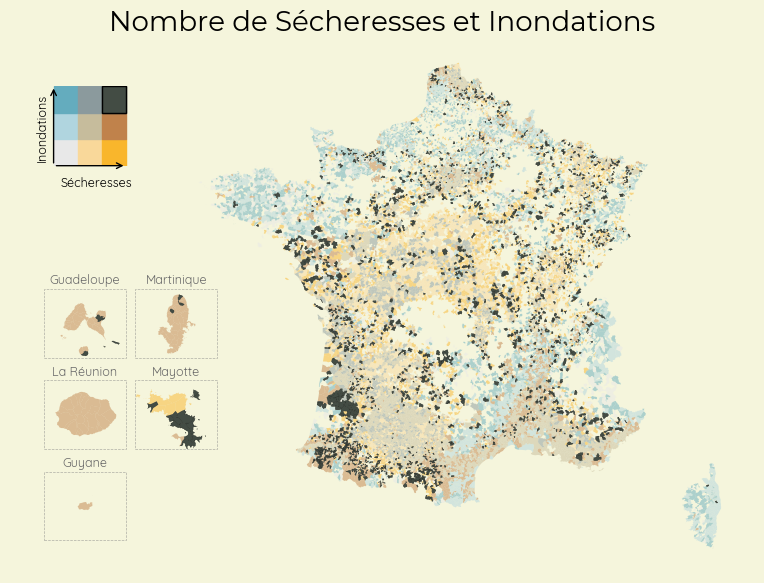

In [129]:
bivariate_map(df=communes_geo_params,
              cols=["num_sécheresse", "num_inondations"],
              title="Nombre de Sécheresses et Inondations",
              legend_labels=["Sécheresses", "Inondations"],
              colors=colors_,
              focus=True);

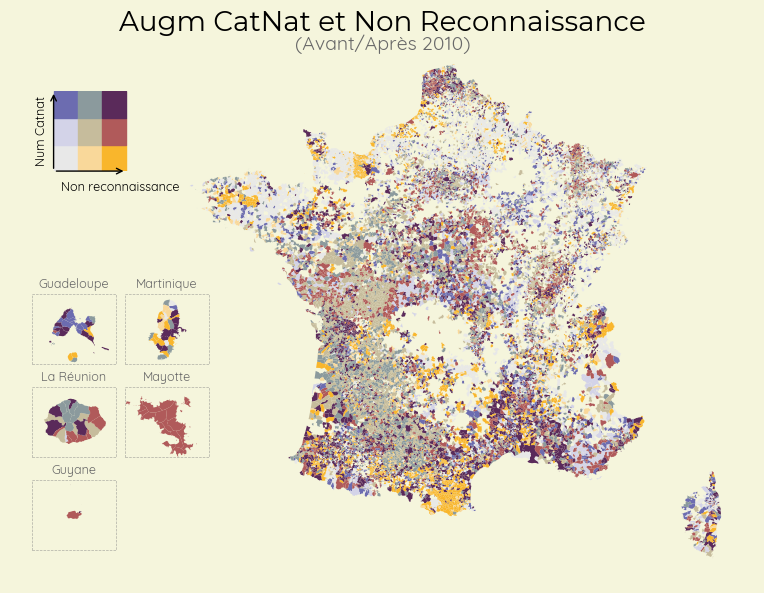

In [130]:
colors_purple_orange = [
        "#e8e8e8", "#d3d3e8", "#6c6cb0", 
        "#f9d89a", "#c6bc9c", "#8b9a9d", 
        "#f9b62c", "#b05a5a", "#5a2a5a"  
    ]

bivariate_map(df=communes_geo_params,
              cols=["taux_non_rec_growth", "freq_growth"],
              title="Augmentation CatNat et Non Reconnaissance",
              legend_labels=["Non reconnaissance", "Num Catnat"],
              colors=colors_purple_orange,
              subtitle="(Avant/Après 2010)",
              focus=False);

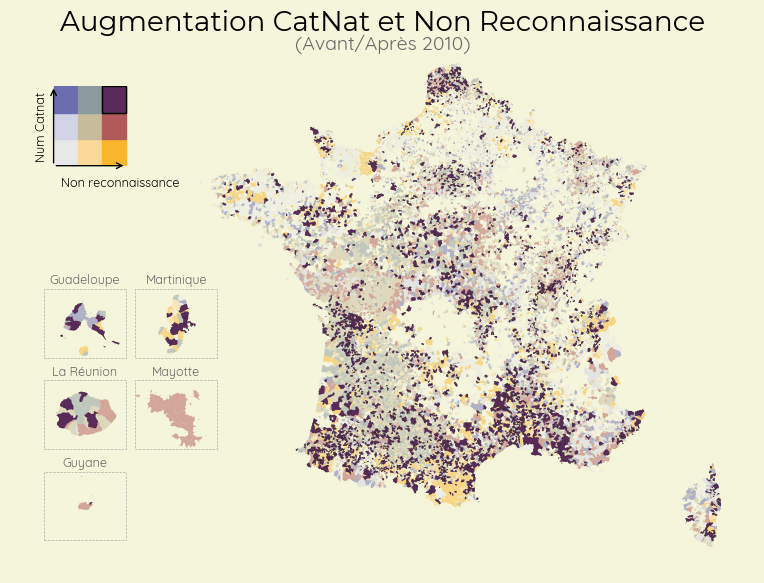

In [131]:
bivariate_map(df=communes_geo_params,
              cols=["taux_non_rec_growth", "freq_growth"],
              title="Augmentation CatNat et Non Reconnaissance",
              legend_labels=["Non reconnaissance", "Num Catnat"],
              colors=colors_purple_orange,
              subtitle="(Avant/Après 2010)",
              focus=True);

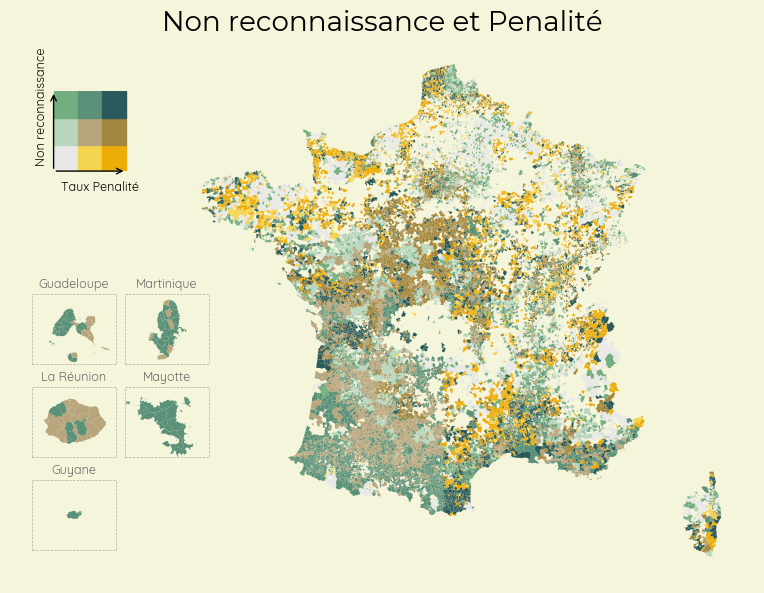

In [134]:
colors_vibrant_ob = [
    "#e8e8e8", "#b8d6be", "#73ae80",
    "#f5d44f", "#b8a57d", "#5a9178",
    "#edad08", "#a3863d", "#2a5a5b" 
]

bivariate_map(df=communes_geo_params,
              cols=["taux_penalite_global", "taux_non_rec_global"],
              title="Non reconnaissance et Penalité",
              legend_labels=["Taux Penalité", "Non reconnaissance"],
              colors=colors_vibrant_ob,
              focus=False);

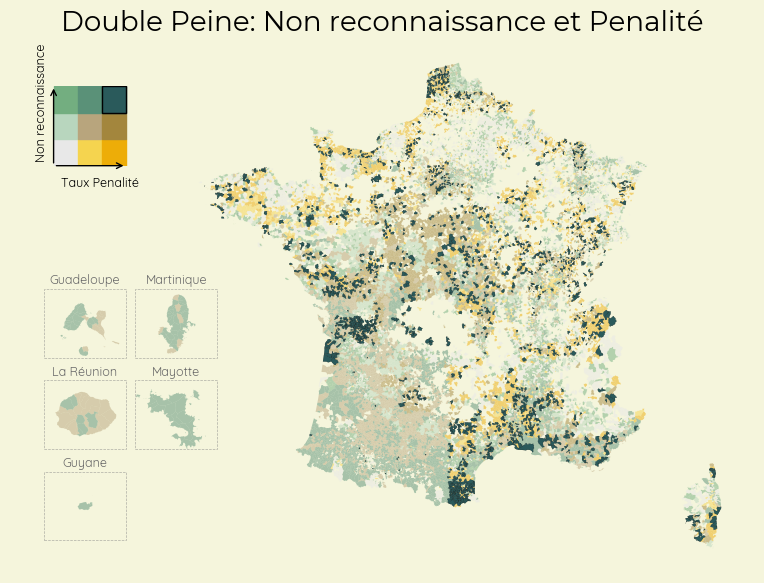

In [136]:
bivariate_map(df=communes_geo_params,
              cols=["taux_penalite_global", "taux_non_rec_global"],
              title="Double Peine: Non reconnaissance et Penalité",
              legend_labels=["Taux Penalité", "Non reconnaissance"],
              colors=colors_vibrant_ob,
              focus=True);

## __GIF__

In [150]:
def create_catnat_franchise_gif(df,
                                duration=1000, # 1 ms per frame
                                years = np.arange(2000, 2026),
                                output_file="franchise_evolution.gif"):
    CONFIG = {
        "Simple": {"rank": 1, "color": "#4F7942"},
        "Doublée": {"rank": 2, "color": "#feb24c"},
        "Triplée": {"rank": 3, "color": "#e31a1c"},
        "Quadruplée": {"rank": 4, "color": "#8B0000"}
    }
    
    penalty_to_rank = {k: v['rank'] for k, v in CONFIG.items()}
    rank_to_color = {v['rank']: v['color'] for k, v in CONFIG.items()}
    
    df = df.copy()
    df['year'] = pd.to_datetime(df['dateArrete']).dt.year
    df['p_rank'] = df['franchise'].map(penalty_to_rank).fillna(0).astype(int)

    base_gdf, drom_configs = prepare_france_geometry(communes_geo.copy())
    base_gdf = base_gdf.set_index('code') 
    
    temp_dir = Path("temp_frames_franchise")
    temp_dir.mkdir(parents=True, exist_ok=True)
    filenames = []

    legend_patches = [mpatches.Patch(color=v['color'], label=k) for k, v in CONFIG.items()]
 
    running_status = pd.Series(0, index=base_gdf.index)    
    for year in tqdm(years):

        df_year = df[df['year'] == year]
        if not df_year.empty:
            # Get the new ranks for this year
            yearly_data = df_year.groupby('codeInsee')['p_rank'].max()
            running_status.update(yearly_data)
        
        fig, ax = plt.subplots(figsize=(10, 10))
        base_gdf.plot(ax=ax, color='#B2BEB5', edgecolor='dimgrey', linewidth=0.05)

        active_mask = running_status > 0
        if active_mask.any():
            active_idx = running_status[active_mask].index
            active_gdf = base_gdf.loc[active_idx].copy()
            active_gdf['color'] = running_status.loc[active_idx].map(rank_to_color)
            
            active_gdf.plot(
                ax=ax, 
                color=active_gdf['color'], 
                edgecolor='black', 
                linewidth=0.05
            )

        # Draw DROM boxes (Static)
        box_w, box_h = 180000, 150000 
        for code, cfg in drom_configs.items():
            x, y = cfg['pos']
            rect = mpatches.Rectangle((x - box_w/2, y - box_h/2), box_w, box_h,
                                     linewidth=0.5, edgecolor='gray', facecolor='none', 
                                     linestyle='--', alpha=0.4)
            ax.add_patch(rect)
            ax.text(x, y + (box_h/2) + 12500, cfg['name'], fontsize=9, ha='center', color='dimgray')

        # Annotations
        ax.set_axis_off()
        ax.legend(handles=legend_patches, loc='center right', frameon=False, labelcolor="black")
        ax.text(0.02, 0.9, f"Franchises CatNat: {year}", transform=ax.transAxes, 
                fontsize=20, fontweight='bold', color='#333333')
    
        # Save frame
        frame_path = temp_dir / f"frame_{year}.png"
        plt.savefig(frame_path, dpi=100, bbox_inches='tight')
        plt.close()
        filenames.append(frame_path)

    with imageio.get_writer(output_file, mode='I', duration=500, loop=0) as writer:
        for f in filenames:
            writer.append_data(imageio.imread(f))


create_catnat_franchise_gif(ccr_details_df[ccr_details_df["franchise"] != '-'])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [08:02<00:00, 18.56s/it]


In [149]:
ccr_details_df

,codeInsee,nomCommune,dateDebutEvenement,dateFinEvenement,dateArrete,dateParutionJO,nomPeril,franchise,libelleAvis,code_arrete
0,07005,ALBA LA ROMAINE,2025-11-16,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,-,Non reconnue,904
1,07022,BAIX,2025-11-16,2025-11-17,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,Simple,Reconnue,904
2,07181,LE POUZIN,2025-11-16,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,-,Non reconnue,904
3,07198,ROMPON,2025-11-15,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,-,Non reconnue,904
4,07219,SAINT BAUZILE,2025-11-16,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,Simple,Reconnue,904
...,...,...,...,...,...,...,...,...,...,...
243027,69009,ANSE,1982-08-16,1982-08-16,1982-09-21,1982-09-30,Inondations et/ou Coulées de Boue,Simple,Reconnue,48
243028,69052,CHAZAY D AZERGUES,1982-08-16,1982-08-16,1982-09-21,1982-09-30,Inondations et/ou Coulées de Boue,Simple,Reconnue,48
243029,69122,LUCENAY,1982-08-16,1982-08-16,1982-09-21,1982-09-30,Inondations et/ou Coulées de Boue,Simple,Reconnue,48
243030,69140,MORANCE,1982-08-16,1982-08-16,1982-09-21,1982-09-30,Inondations et/ou Coulées de Boue,Simple,Reconnue,48


## PPRN & PPRI

In [235]:
query_ccr_main = """
SELECT
	*
FROM dev.main.tim_gaspar
"""

ccr_main = con.sql(query_ccr_main)
ccr_main_df = ccr_main.df()
ccr_main_df.head(2)

,codeInsee,nomCommune,dateDebutEvenement,dateFinEvenement,dateArrete,dateParutionJO,nomPeril,franchise,libelleAvis,code_arrete
0,07005,ALBA LA ROMAINE,2025-11-16,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,-,Non reconnue,904
1,07022,BAIX,2025-11-16,2025-11-17,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,Simple,Reconnue,904
